# Japan Protein Cost-Efficiency Analysis
## Notebook 03b — Amino Acid Profile Analysis

**Goal:** Extract individual amino acid data from USDA SR Legacy for all 31 protein sources, with focus on muscle-relevant amino acids for bodybuilding and weightlifting applications.

**Why this matters:**
DIAAS captures overall protein quality but doesn't reveal *which* amino acids are limiting or *how much* of the key muscle-building amino acids each food delivers. For athletes and bodybuilders, leucine content is particularly important as it directly triggers muscle protein synthesis (MPS).

**Key amino acids of interest:**
| Amino acid | Role | Why it matters |
|---|---|---|
| Leucine | Primary MPS trigger | Most important for muscle building |
| Isoleucine | BCAA, energy during training | Supports MPS and recovery |
| Valine | BCAA, recovery | Reduces muscle fatigue |
| Lysine | Muscle repair | Often limiting in plant proteins |
| Methionine | Sulphur AA, connective tissue | Often limiting in legumes |
| Threonine | Muscle protein structure | Second most limiting in plant proteins |
| Total BCAA | Leu + Ile + Val | Standard bodybuilding metric |

**Data source:** USDA SR Legacy — `food_nutrient.csv` (already downloaded in Notebook 01)
**Input:** `nutrients_diaas.csv` from Notebook 03

**Author:** Anthony Disorbo
**Last updated:** 2026-06

---
> **Note:** Amino acid values are per 100g edible portion, raw weight, consistent with all other notebooks in this project.

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import io
import os
from pathlib import Path
from bs4 import BeautifulSoup
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


In [ ]:
# Authenticate and connect to Google Drive
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()
service = build('drive', 'v3', credentials=creds)

DRIVE_FOLDER_ID = '17Jcona7Ur-iV7miakhLkhHGBgggT0to7'  # food_data folder

print('Drive service ready ✓')

Drive service ready ✓


In [ ]:
# Download nutrients_diaas.csv from Drive
results = service.files().list(
    q=f"name='nutrients_diaas.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

if not results['files']:
    print('⚠️  nutrients_diaas.csv not found in Drive — check DRIVE_FOLDER_ID or run Notebook 03 first')
else:
    file_id = results['files'][0]['id']
    request = service.files().get_media(fileId=file_id)
    fh = io.BytesIO()
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()

    fh.seek(0)
    df = pd.read_csv(fh)
    print(f'nutrients_diaas loaded: {df.shape[0]} rows × {df.shape[1]} columns')
    df[['food_key', 'source_category', 'protein_g', 'price_jpy_per_100g',
        'yen_per_g_protein', 'diaas_score', 'adjusted_yen_per_g']].head(10)

nutrients_diaas loaded: 31 rows × 19 columns


In [ ]:
# Re-download SR Legacy CSV files from Drive
# (Colab temp storage resets between sessions)

FILES_TO_DOWNLOAD = {
    'food.csv':          '10UHetV9sP1yCi26dNyM4wZWGt1iRt6mf',
    'food_nutrient.csv': '1pwmbhKSc6ioCJduofZKMtrhgyHdjjdlE',
    'nutrient.csv':      '1y3W3FClUdxnSGUe3QpjYWdOM0rNE5WIx',
    'food_portion.csv':  '1m5MRxcxWtz9b_43NGKaHTmEDfOYz7lem',
}

LOCAL_DIR = '/content/sr_legacy/'
os.makedirs(LOCAL_DIR, exist_ok=True)

for filename, file_id in FILES_TO_DOWNLOAD.items():
    local_path = LOCAL_DIR + filename
    if os.path.exists(local_path):
        print(f'✓ {filename} already exists — skipping')
        continue
    request = service.files().get_media(fileId=file_id)
    fh = io.FileIO(local_path, 'wb')
    downloader = MediaIoBaseDownload(fh, request)
    done = False
    while not done:
        _, done = downloader.next_chunk()
    print(f'✓ Downloaded {filename}')

print('\nAll files ready.')

✓ Downloaded food.csv
✓ Downloaded food_nutrient.csv
✓ Downloaded nutrient.csv
✓ Downloaded food_portion.csv

All files ready.


In [ ]:
# ============================================================
# LOAD DATA
# 1. nutrients_diaas.csv — our 26-food master table from NB03
# 2. food_nutrient.csv — full USDA nutrient values (already in Colab)
# 3. nutrient.csv — nutrient ID lookup
# ============================================================

# Load master table from Drive
results = service.files().list(
    q=f"name='nutrients_diaas.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()

file_id = results['files'][0]['id']
request = service.files().get_media(fileId=file_id)
fh = io.BytesIO()
downloader = MediaIoBaseDownload(fh, request)
done = False
while not done:
    _, done = downloader.next_chunk()
fh.seek(0)
df = pd.read_csv(fh)
print(f'nutrients_diaas loaded: {df.shape[0]} rows')

# Load USDA files from Colab temp storage
LOCAL_DIR = '/content/sr_legacy/'
food_nutrient = pd.read_csv(LOCAL_DIR + 'food_nutrient.csv')
nutrient      = pd.read_csv(LOCAL_DIR + 'nutrient.csv')

print(f'food_nutrient loaded : {food_nutrient.shape[0]:,} rows')
print(f'nutrient loaded      : {nutrient.shape[0]:,} rows')
print(f'\nSample nutrient names:')
print(nutrient[['id','name','unit_name']].head(20).to_string(index=False))

nutrients_diaas loaded: 31 rows
food_nutrient loaded : 644,125 rows
nutrient loaded      : 474 rows

Sample nutrient names:
  id                                 name unit_name
2047     Energy (Atwater General Factors)      KCAL
2048    Energy (Atwater Specific Factors)      KCAL
1001                               Solids         G
1002                             Nitrogen         G
1003                              Protein         G
1004                    Total lipid (fat)         G
1005          Carbohydrate, by difference         G
1006 Fiber, crude (DO NOT USE - Archived)         G
1007                                  Ash         G
1008                               Energy      KCAL
1009                               Starch         G
1010                              Sucrose         G
1011                              Glucose         G
1012                             Fructose         G
1013                              Lactose         G
1014                              Maltose   

In [ ]:
# Search for amino acids in the nutrient table
aa_keywords = ['leucine', 'isoleucine', 'valine', 'lysine',
               'methionine', 'threonine', 'tryptophan',
               'phenylalanine', 'histidine', 'arginine',
               'alanine', 'glycine', 'proline', 'serine',
               'tyrosine', 'cystine', 'glutamic', 'aspartic',
               'amino']

mask = nutrient['name'].str.lower().str.contains('|'.join(aa_keywords), na=False)
aa_nutrients = nutrient[mask][['id', 'name', 'unit_name']].sort_values('id')

print(f'Found {len(aa_nutrients)} amino acid-related nutrients:\n')
print(aa_nutrients.to_string(index=False))

Found 23 amino acid-related nutrients:

  id                                         name unit_name
1168           Niacin from tryptophan, determined        MG
1210                                   Tryptophan         G
1211                                    Threonine         G
1212                                   Isoleucine         G
1213                                      Leucine         G
1214                                       Lysine         G
1215                                   Methionine         G
1216                                      Cystine         G
1217                                Phenylalanine         G
1218                                     Tyrosine         G
1219                                       Valine         G
1220                                     Arginine         G
1221                                    Histidine         G
1222                                      Alanine         G
1223                                Aspartic acid         G


In [ ]:
# ============================================================
# AMINO ACID NUTRIENT ID MAP
# Focus: 9 IAAs + conditionally essential + muscle-relevant
# ============================================================

AA_CODES = {
    # 9 Indispensable Amino Acids (IAAs)
    1210: 'tryptophan',
    1211: 'threonine',
    1212: 'isoleucine',
    1213: 'leucine',
    1214: 'lysine',
    1215: 'methionine',
    1216: 'cystine',
    1217: 'phenylalanine',
    1218: 'tyrosine',
    1219: 'valine',
    1221: 'histidine',

    # Dispensable — useful for muscle/connective tissue context
    1220: 'arginine',
    1222: 'alanine',
    1223: 'aspartic_acid',
    1224: 'glutamic_acid',
    1225: 'glycine',
    1226: 'proline',
    1227: 'serine',
}

# Filter food_nutrient to only our foods and amino acids
fdc_ids = df['fdc_id'].unique().tolist()

aa_data = food_nutrient[
    (food_nutrient['fdc_id'].isin(fdc_ids)) &
    (food_nutrient['nutrient_id'].isin(AA_CODES.keys()))
][['fdc_id', 'nutrient_id', 'amount']].copy()

aa_data['nutrient_id'] = aa_data['nutrient_id'].map(AA_CODES)

# Pivot to wide format
aa_wide = aa_data.pivot_table(
    index='fdc_id', columns='nutrient_id', values='amount', aggfunc='first'
).reset_index()

# Merge with food keys
aa_wide = df[['food_key', 'fdc_id', 'source_category']].merge(aa_wide, on='fdc_id', how='left')

print(f'Amino acid table: {aa_wide.shape[0]} rows × {aa_wide.shape[1]} columns')
print(f'\nMissing values per amino acid:')
print(aa_wide.isnull().sum()[aa_wide.isnull().sum() > 0])
aa_wide.head(31)

Amino acid table: 31 rows × 21 columns

Missing values per amino acid:
alanine          2
arginine         2
aspartic_acid    2
cystine          2
glutamic_acid    2
glycine          2
histidine        2
isoleucine       2
leucine          2
lysine           2
methionine       2
phenylalanine    2
proline          2
serine           2
threonine        2
tryptophan       2
tyrosine         2
valine           2
dtype: int64


,food_key,fdc_id,source_category,alanine,arginine,aspartic_acid,cystine,glutamic_acid,glycine,histidine,isoleucine,leucine,lysine,methionine,phenylalanine,proline,serine,threonine,tryptophan,tyrosine,valine
0,chicken_breast,171474,poultry,1.19,1.29,1.86,0.27,3.08,1.23,0.62,1.06,1.53,1.73,0.56,0.82,0.95,0.73,0.87,0.24,0.68,1.02
1,chicken_thigh,172385,poultry,1.01,1.16,1.55,0.18,2.57,1.00,0.47,0.73,1.32,1.45,0.44,0.63,0.77,0.68,0.73,0.17,0.58,0.76
2,chicken_sasami,171474,poultry,1.19,1.29,1.86,0.27,3.08,1.23,0.62,1.06,1.53,1.73,0.56,0.82,0.95,0.73,0.87,0.24,0.68,1.02
3,chicken_wing_tip,172390,poultry,1.02,1.19,1.65,0.18,2.60,0.78,0.65,0.86,1.45,1.69,0.46,0.71,0.56,0.67,0.79,0.22,0.63,0.91
4,chicken_wing_moto,172390,poultry,1.02,1.19,1.65,0.18,2.60,0.78,0.65,0.86,1.45,1.69,0.46,0.71,0.56,0.67,0.79,0.22,0.63,0.91
5,canned_chicken,171110,poultry,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,pork_tonkatsu,167818,pork,1.16,1.25,1.81,0.25,3.04,1.02,0.77,0.91,1.57,1.77,0.51,0.79,0.84,0.81,0.89,0.24,0.68,1.06
7,pork_shougayaki,167818,pork,1.16,1.25,1.81,0.25,3.04,1.02,0.77,0.91,1.57,1.77,0.51,0.79,0.84,0.81,0.89,0.24,0.68,1.06
8,pork_shabushabu,167818,pork,1.16,1.25,1.81,0.25,3.04,1.02,0.77,0.91,1.57,1.77,0.51,0.79,0.84,0.81,0.89,0.24,0.68,1.06
9,pork_loin,167818,pork,1.16,1.25,1.81,0.25,3.04,1.02,0.77,0.91,1.57,1.77,0.51,0.79,0.84,0.81,0.89,0.24,0.68,1.06


In [ ]:
# ============================================================
# WHEY PROTEIN AA PROFILE — WPC-C
# Source: Gilmour SR, Holroyd SE, Fuad MD, Elgar D, Fanning AC.
# "Amino Acid Composition of Dried Bovine Dairy Powders from
# a Range of Product Streams." Fonterra Research and Development
# Centre. Values from WPC-C column (mg/g protein).
# Converted to g/100g product using whey protein content: 58.14g/100g
# Formula: mg/g_protein × protein_g/100g ÷ 1000 = g/100g_product
# ============================================================

WHEY_PROTEIN_G = 58.14  # from USDA fdc_id 173177

# WPC-C values in mg/g protein (mean values, no SD)
WPC_C_MG_PER_G_PROTEIN = {
    'alanine':       58.9,
    'arginine':      25.9,
    'aspartic_acid': 120.6,
    'cystine':       28.3,
    'glutamic_acid': 189.2,
    'glycine':       20.6,
    'histidine':     19.0,
    'isoleucine':    66.0,
    'leucine':       114.1,
    'lysine':        102.1,
    'methionine':    25.0,
    'phenylalanine': 33.5,
    'proline':       65.5,
    'serine':        58.1,
    'threonine':     82.7,
    'tryptophan':    23.8,
    'tyrosine':      31.1,
    'valine':        63.4,
}

# Convert to g/100g product
WHEY_AA = {
    aa: round(mg_per_g * WHEY_PROTEIN_G / 1000, 2)
    for aa, mg_per_g in WPC_C_MG_PER_G_PROTEIN.items()
}

print('=== WPC-C AA profile converted to g/100g product ===')
print(f'Protein content used: {WHEY_PROTEIN_G}g/100g\n')
for aa, val in WHEY_AA.items():
    print(f'  {aa:20s}: {val:.2f}g')

# Apply to aa_wide
for aa, val in WHEY_AA.items():
    if aa in aa_wide.columns:
        aa_wide.loc[aa_wide['food_key'] == 'whey_protein', aa] = val

print('\n✓ Whey protein AA profile applied')
print(aa_wide[aa_wide['food_key'] == 'whey_protein'][
    ['food_key', 'leucine', 'lysine', 'isoleucine', 'valine', 'threonine']
].to_string(index=False))

=== WPC-C AA profile converted to g/100g product ===
Protein content used: 58.14g/100g

  alanine             : 3.42g
  arginine            : 1.51g
  aspartic_acid       : 7.01g
  cystine             : 1.65g
  glutamic_acid       : 11.00g
  glycine             : 1.20g
  histidine           : 1.10g
  isoleucine          : 3.84g
  leucine             : 6.63g
  lysine              : 5.94g
  methionine          : 1.45g
  phenylalanine       : 1.95g
  proline             : 3.81g
  serine              : 3.38g
  threonine           : 4.81g
  tryptophan          : 1.38g
  tyrosine            : 1.81g
  valine              : 3.69g

✓ Whey protein AA profile applied
    food_key  leucine  lysine  isoleucine  valine  threonine
whey_protein     6.63    5.94        3.84    3.69       4.81


In [ ]:
# ============================================================
# CANNED CHICKEN AA PROFILE — scaled from chicken breast
# Source: USDA SR Legacy fdc_id 171474 (chicken breast, raw)
# Method: AA ratios preserved through canning (heat denaturation
# changes protein structure but not amino acid composition).
# Scale factor = canned chicken protein / breast protein
#              = 25.30 / 20.85 = 1.213
# Note: this is an approximation — no direct AA analysis for
# fdc_id 171110 exists in USDA SR Legacy.
# ============================================================

BREAST_AA = aa_wide[aa_wide['food_key'] == 'chicken_breast'].iloc[0]
SCALE = 25.30 / 20.85

print(f'Scale factor: {SCALE:.3f}')
print(f'Breast protein: 20.85g | Canned protein: 25.30g\n')

CANNED_CHICKEN_AA = {}
for aa in WPC_C_MG_PER_G_PROTEIN.keys():
    if aa in aa_wide.columns:
        val = round(float(BREAST_AA[aa]) * SCALE, 2)
        CANNED_CHICKEN_AA[aa] = val

for aa, val in CANNED_CHICKEN_AA.items():
    aa_wide.loc[aa_wide['food_key'] == 'canned_chicken', aa] = val

print('✓ Canned chicken AA profile applied')
print(aa_wide[aa_wide['food_key'] == 'canned_chicken'][
    ['food_key', 'leucine', 'lysine', 'isoleucine', 'valine', 'threonine']
].to_string(index=False))

# Final check — no missing values in key AAs
key_aas = ['leucine', 'isoleucine', 'valine', 'lysine', 'methionine', 'threonine', 'tryptophan']
missing = aa_wide[key_aas].isnull().sum()
print(f'\nMissing values in key AAs after all hardcoding:')
print(missing[missing > 0] if missing.any() else '✓ None — all 31 foods complete')

Scale factor: 1.213
Breast protein: 20.85g | Canned protein: 25.30g

✓ Canned chicken AA profile applied
      food_key  leucine  lysine  isoleucine  valine  threonine
canned_chicken     1.86    2.09        1.29    1.24       1.05

Missing values in key AAs after all hardcoding:
✓ None — all 31 foods complete


In [ ]:
# ============================================================
# MUSCLE-RELEVANT AMINO ACID METRICS
# 1. Total BCAA (Leucine + Isoleucine + Valine) per 100g
# 2. Leucine per 100g — primary MPS trigger
# 3. Lysine per 100g — most limiting AA in plant proteins
# 4. BCAA per ¥100 spent — cost efficiency for athletes
# 5. Leucine per ¥100 spent — most actionable bodybuilding metric
# ============================================================

# Merge AA data with price data
aa_merged = aa_wide.merge(
    df[['food_key', 'price_jpy_per_100g', 'yen_per_g_protein',
        'adjusted_yen_per_g', 'diaas_score', 'protein_g']],
    on='food_key', how='left'
)

# Calculate muscle metrics
aa_merged['total_bcaa_g']        = (aa_merged['leucine'] +
                                    aa_merged['isoleucine'] +
                                    aa_merged['valine']).round(2)
aa_merged['bcaa_per_100yen']     = (aa_merged['total_bcaa_g'] /
                                    aa_merged['price_jpy_per_100g'] * 100).round(2)
aa_merged['leucine_per_100yen']  = (aa_merged['leucine'] /
                                    aa_merged['price_jpy_per_100g'] * 100).round(2)
aa_merged['lysine_per_100yen']   = (aa_merged['lysine'] /
                                    aa_merged['price_jpy_per_100g'] * 100).round(2)

# Rankings
aa_merged['bcaa_rank']    = aa_merged['bcaa_per_100yen'].rank(ascending=False).astype(int)
aa_merged['leucine_rank'] = aa_merged['leucine_per_100yen'].rank(ascending=False).astype(int)

print('=== Muscle Amino Acid Metrics ===\n')
print('--- BCAA per 100g (absolute content) ---')
print(aa_merged.sort_values('total_bcaa_g', ascending=False)[
    ['food_key', 'source_category', 'protein_g', 'leucine', 'isoleucine', 'valine', 'total_bcaa_g']
].to_string(index=False))

print('\n--- Leucine per ¥100 spent (bodybuilder cost metric) ---')
print(aa_merged.sort_values('leucine_per_100yen', ascending=False)[
    ['food_key', 'source_category', 'leucine', 'price_jpy_per_100g', 'leucine_per_100yen', 'leucine_rank']
].to_string(index=False))

=== Muscle Amino Acid Metrics ===

--- BCAA per 100g (absolute content) ---
         food_key source_category  protein_g  leucine  isoleucine  valine  total_bcaa_g
      soy_protein           plant      88.32     6.78        4.25    4.10         15.13
     whey_protein           dairy      58.14     6.63        3.84    3.69         14.16
      canned_tuna         seafood      25.51     2.07        1.18    1.31          4.56
   canned_chicken         poultry      25.30     1.86        1.29    1.24          4.39
       fresh_tuna         seafood      23.33     1.90        1.07    1.20          4.17
   chicken_sasami         poultry      20.85     1.53        1.06    1.02          3.62
   chicken_breast         poultry      20.85     1.53        1.06    1.02          3.62
     fresh_salmon         seafood      19.84     1.61        0.91    1.02          3.55
        pork_loin            pork      19.74     1.57        0.91    1.06          3.55
  pork_shabushabu            pork      19.74

In [ ]:
# Collapse duplicates
DROP_LIST = ['pork_tonkatsu', 'pork_shougayaki', 'pork_shabushabu',
             'beef_usugiri', 'beef_loin']

aa_merged = aa_merged[~aa_merged['food_key'].isin(DROP_LIST)].copy().reset_index(drop=True)

# Recalculate ranks after dropping duplicates
aa_merged['bcaa_rank']    = aa_merged['bcaa_per_100yen'].rank(ascending=False).astype(int)
aa_merged['leucine_rank'] = aa_merged['leucine_per_100yen'].rank(ascending=False).astype(int)

print(f'Dataset: {len(aa_merged)} foods after consolidation')
print(aa_merged['food_key'].tolist())

Dataset: 26 foods after consolidation
['chicken_breast', 'chicken_thigh', 'chicken_sasami', 'chicken_wing_tip', 'chicken_wing_moto', 'canned_chicken', 'pork_loin', 'beef_american_cab', 'beef_wagyu_steak', 'fresh_salmon', 'fresh_mackerel', 'fresh_squid', 'fresh_white_fish', 'fresh_tuna', 'canned_tuna', 'natto', 'tofu_momen', 'tofu_kinu', 'chicken_egg', 'quail_egg', 'milk_whole', 'yogurt_plain', 'greek_yogurt', 'whey_protein', 'soy_protein', 'edamame']


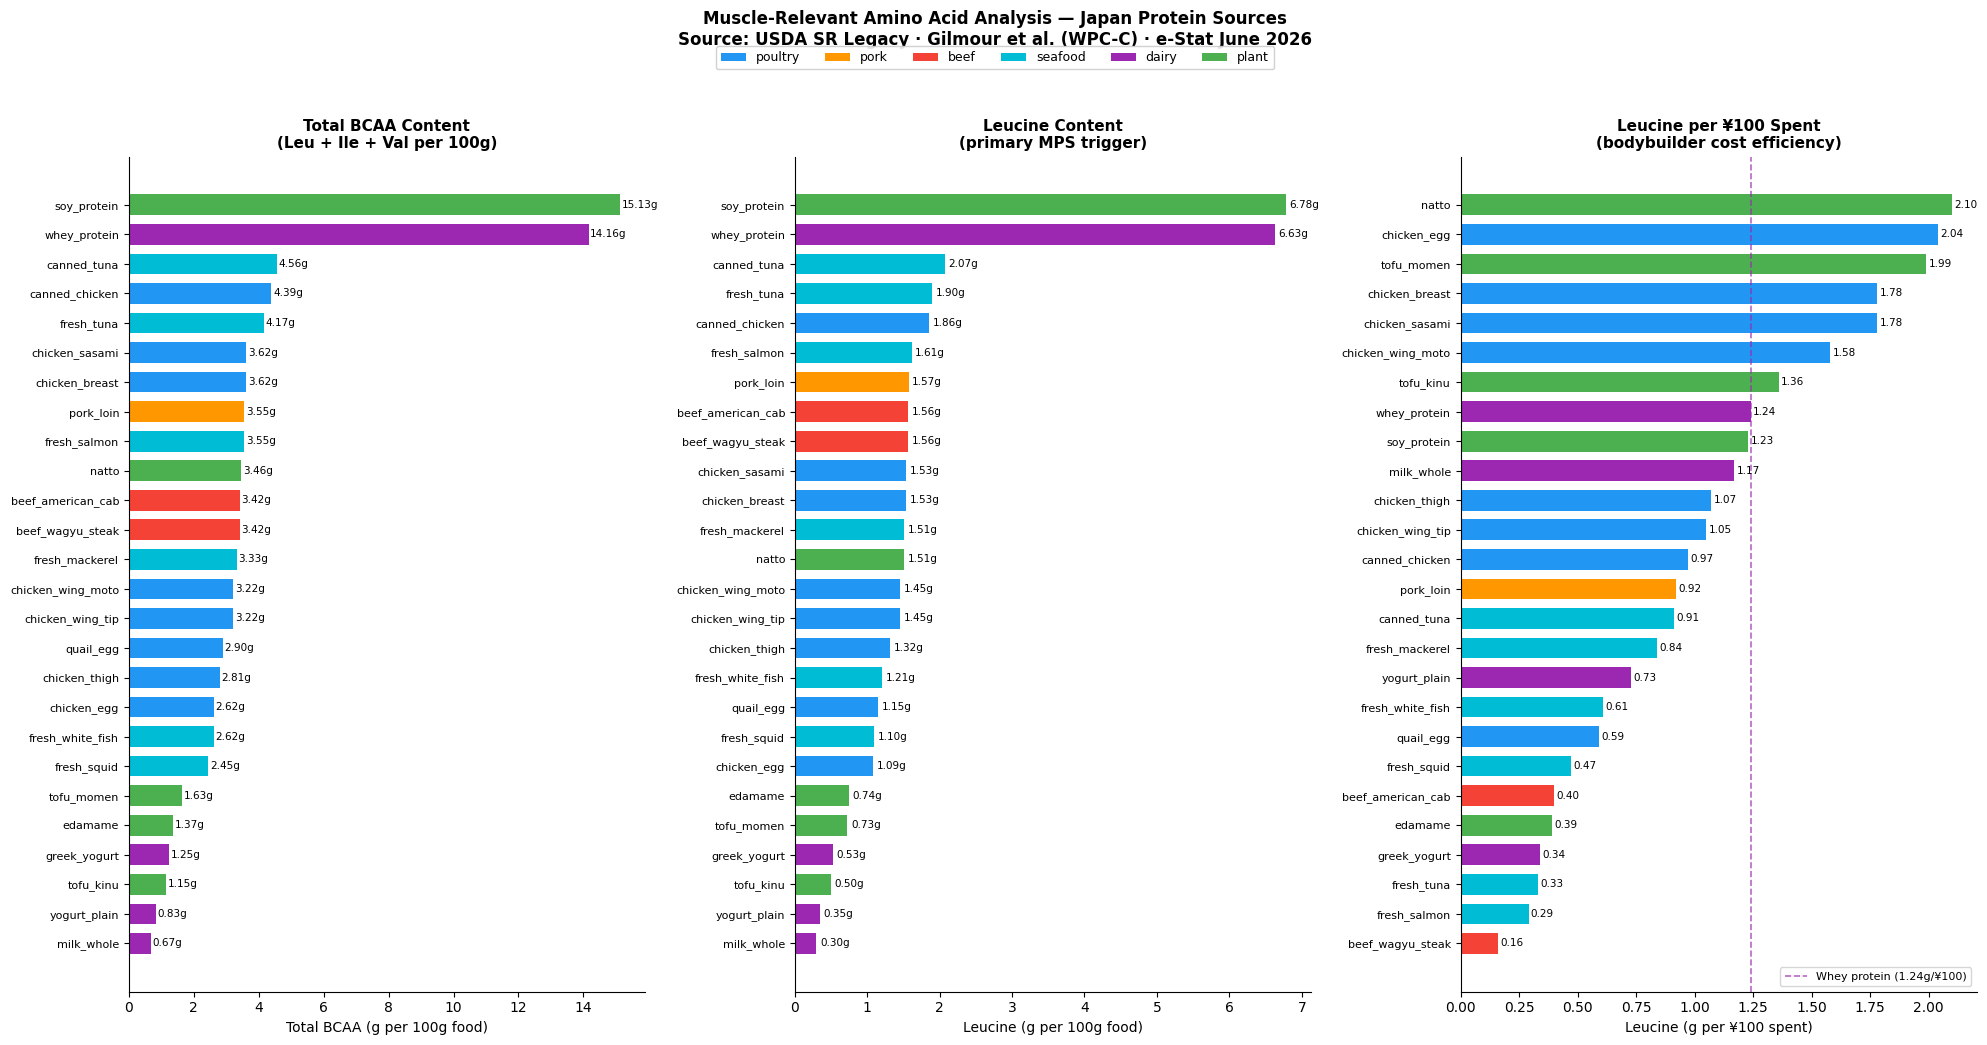

Chart saved ✓


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

# --- Panel 1: Total BCAA per 100g (absolute content) ---
ax1 = axes[0]
p1 = aa_merged.sort_values('total_bcaa_g', ascending=True)
colors1 = [CAT_COLORS[c] for c in p1['source_category']]
bars1 = ax1.barh(p1['food_key'], p1['total_bcaa_g'], color=colors1, edgecolor='none', height=0.7)
for bar, val in zip(bars1, p1['total_bcaa_g']):
    ax1.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}g', va='center', fontsize=7.5)
ax1.set_xlabel('Total BCAA (g per 100g food)', fontsize=10)
ax1.set_title('Total BCAA Content\n(Leu + Ile + Val per 100g)', fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=8)

# --- Panel 2: Leucine per 100g ---
ax2 = axes[1]
p2 = aa_merged.sort_values('leucine', ascending=True)
colors2 = [CAT_COLORS[c] for c in p2['source_category']]
bars2 = ax2.barh(p2['food_key'], p2['leucine'], color=colors2, edgecolor='none', height=0.7)
for bar, val in zip(bars2, p2['leucine']):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}g', va='center', fontsize=7.5)
ax2.set_xlabel('Leucine (g per 100g food)', fontsize=10)
ax2.set_title('Leucine Content\n(primary MPS trigger)', fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)

# --- Panel 3: Leucine per ¥100 spent ---
ax3 = axes[2]
p3 = aa_merged.sort_values('leucine_per_100yen', ascending=True)
colors3 = [CAT_COLORS[c] for c in p3['source_category']]
bars3 = ax3.barh(p3['food_key'], p3['leucine_per_100yen'], color=colors3, edgecolor='none', height=0.7)
for bar, val in zip(bars3, p3['leucine_per_100yen']):
    ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=7.5)
# Reference line at whey protein value
whey_val = aa_merged.loc[aa_merged['food_key'] == 'whey_protein', 'leucine_per_100yen'].values[0]
ax3.axvline(x=whey_val, color='#9C27B0', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Whey protein ({whey_val:.2f}g/¥100)')
ax3.set_xlabel('Leucine (g per ¥100 spent)', fontsize=10)
ax3.set_title('Leucine per ¥100 Spent\n(bodybuilder cost efficiency)', fontsize=11, fontweight='bold')
ax3.spines[['top', 'right']].set_visible(False)
ax3.tick_params(axis='y', labelsize=8)
ax3.legend(fontsize=8, loc='lower right')

# Shared category legend
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=legend_elements, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    'Muscle-Relevant Amino Acid Analysis — Japan Protein Sources\n'
    'Source: USDA SR Legacy · Gilmour et al. (WPC-C) · e-Stat June 2026',
    fontsize=12, fontweight='bold', y=1.04
)

plt.tight_layout()

os.makedirs('/content/charts', exist_ok=True)
LOCAL_CHART = '/content/charts/amino_acid_muscle.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

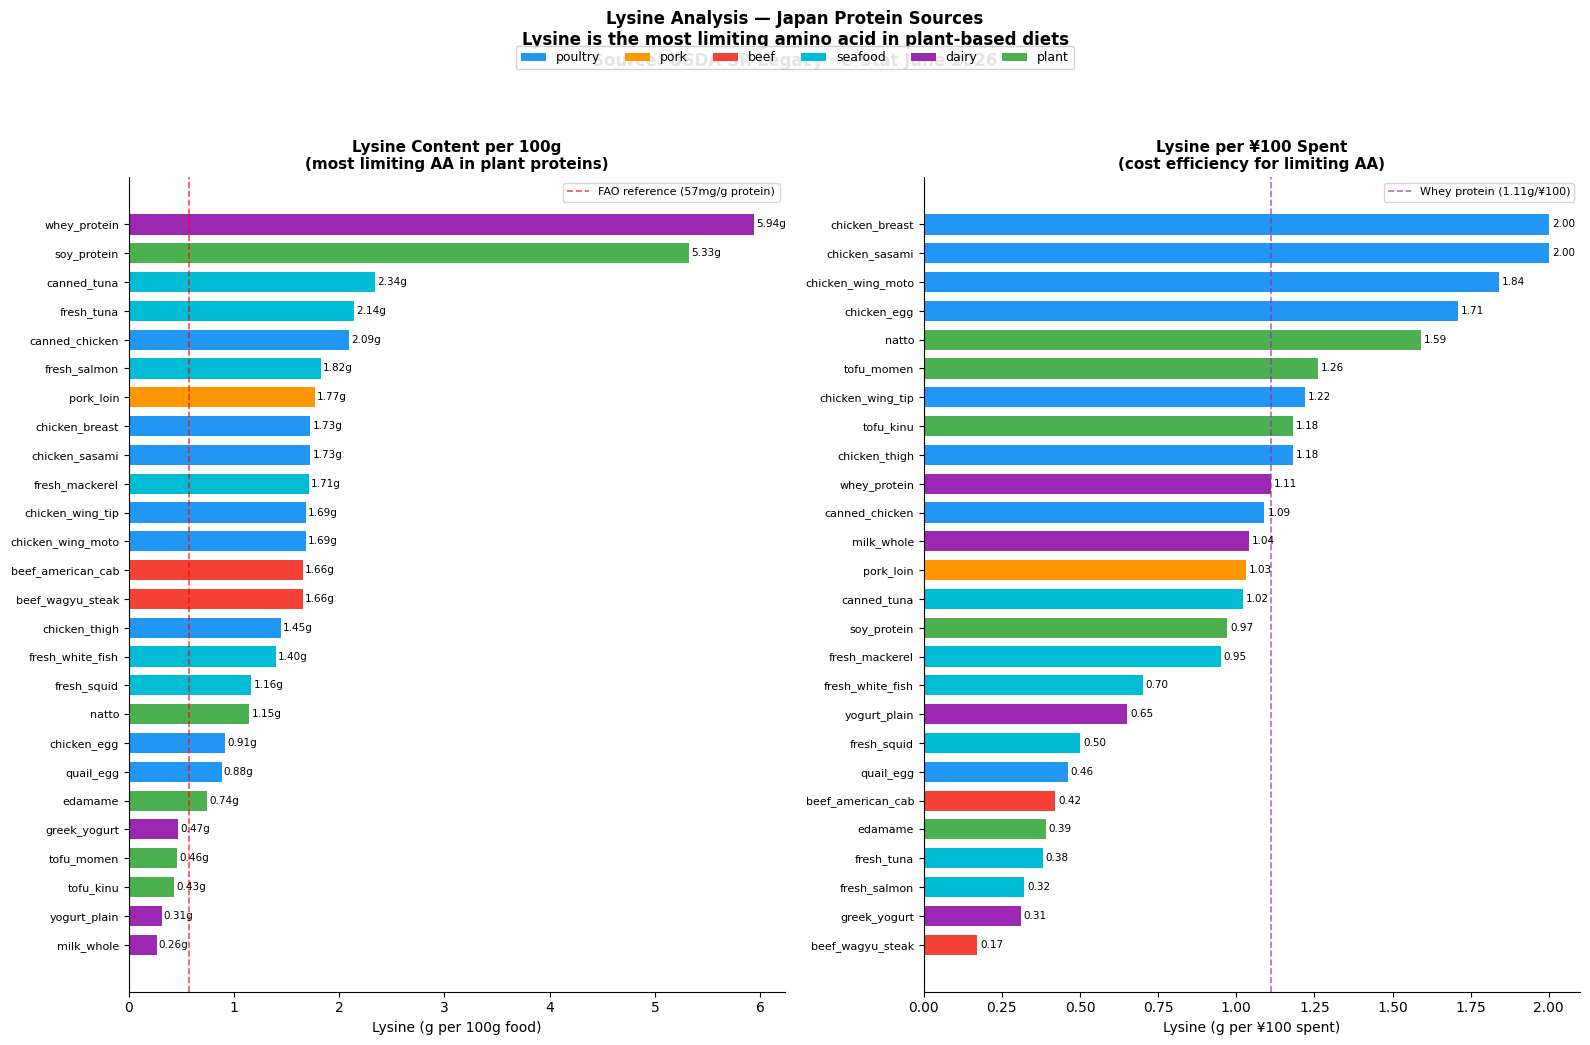

Chart saved ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# --- Panel 1: Lysine per 100g ---
ax1 = axes[0]
p1 = aa_merged.sort_values('lysine', ascending=True)
colors1 = [CAT_COLORS[c] for c in p1['source_category']]
bars1 = ax1.barh(p1['food_key'], p1['lysine'], color=colors1, edgecolor='none', height=0.7)
for bar, val in zip(bars1, p1['lysine']):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}g', va='center', fontsize=7.5)

# FAO reference line for lysine requirement (57mg/g protein × avg protein)
ax1.axvline(x=0.57, color='red', linestyle='--', linewidth=1.2, alpha=0.7,
            label='FAO reference (57mg/g protein)')
ax1.set_xlabel('Lysine (g per 100g food)', fontsize=10)
ax1.set_title('Lysine Content per 100g\n(most limiting AA in plant proteins)',
              fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=8)
ax1.legend(fontsize=8)

# --- Panel 2: Lysine per ¥100 spent ---
ax2 = axes[1]
aa_merged['lysine_per_100yen'] = (
    aa_merged['lysine'] / aa_merged['price_jpy_per_100g'] * 100
).round(2)

p2 = aa_merged.sort_values('lysine_per_100yen', ascending=True)
colors2 = [CAT_COLORS[c] for c in p2['source_category']]
bars2 = ax2.barh(p2['food_key'], p2['lysine_per_100yen'], color=colors2, edgecolor='none', height=0.7)
for bar, val in zip(bars2, p2['lysine_per_100yen']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=7.5)

# Reference line at whey
whey_lys = aa_merged.loc[aa_merged['food_key'] == 'whey_protein', 'lysine_per_100yen'].values[0]
ax2.axvline(x=whey_lys, color='#9C27B0', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Whey protein ({whey_lys:.2f}g/¥100)')
ax2.set_xlabel('Lysine (g per ¥100 spent)', fontsize=10)
ax2.set_title('Lysine per ¥100 Spent\n(cost efficiency for limiting AA)',
              fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)
ax2.legend(fontsize=8)

# Shared legend
legend_elements = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=legend_elements, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 1.01))

fig.suptitle(
    'Lysine Analysis — Japan Protein Sources\n'
    'Lysine is the most limiting amino acid in plant-based diets\n'
    'Source: USDA SR Legacy · e-Stat June 2026',
    fontsize=12, fontweight='bold', y=1.04
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/lysine_analysis.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# SAA ANALYSIS
# Sulphur Amino Acids: Methionine + Cystine combined
# FAO reference pattern: 26mg SAA per g protein
# Often limiting in legumes — complements lysine story
# ============================================================

# Calculate SAA metrics
aa_merged['saa_g'] = (aa_merged['methionine'] + aa_merged['cystine']).round(2)
aa_merged['saa_per_100yen'] = (aa_merged['saa_g'] / aa_merged['price_jpy_per_100g'] * 100).round(2)

# FAO reference: 26mg SAA per g protein → convert to g SAA per 100g food
aa_merged['fao_saa_requirement'] = (aa_merged['protein_g'] * 26 / 1000).round(2)
aa_merged['saa_vs_fao'] = (aa_merged['saa_g'] / aa_merged['fao_saa_requirement']).round(2)
aa_merged['saa_limiting'] = aa_merged['saa_vs_fao'] < 1.0

print('=== SAA Analysis ===')
print('FAO reference: 26mg SAA per g protein')
print('saa_vs_fao < 1.0 = SAA is limiting in this food\n')
print(aa_merged.sort_values('saa_vs_fao', ascending=True)[[
    'food_key', 'source_category', 'methionine', 'cystine',
    'saa_g', 'fao_saa_requirement', 'saa_vs_fao', 'saa_limiting'
]].to_string(index=False))

=== SAA Analysis ===
FAO reference: 26mg SAA per g protein
saa_vs_fao < 1.0 = SAA is limiting in this food

         food_key source_category  methionine  cystine  saa_g  fao_saa_requirement  saa_vs_fao  saa_limiting
       tofu_momen           plant        0.11     0.03   0.14                 0.24        0.58          True
     greek_yogurt           dairy        0.15     0.05   0.20                 0.26        0.77          True
          edamame           plant        0.14     0.12   0.26                 0.31        0.84          True
            natto           plant        0.21     0.22   0.43                 0.50        0.86          True
        tofu_kinu           plant        0.08     0.09   0.18                 0.19        0.95          True
      soy_protein           plant        1.13     1.05   2.18                 2.30        0.95          True
       milk_whole           dairy        0.08     0.02   0.10                 0.08        1.25         False
      fresh_squid   

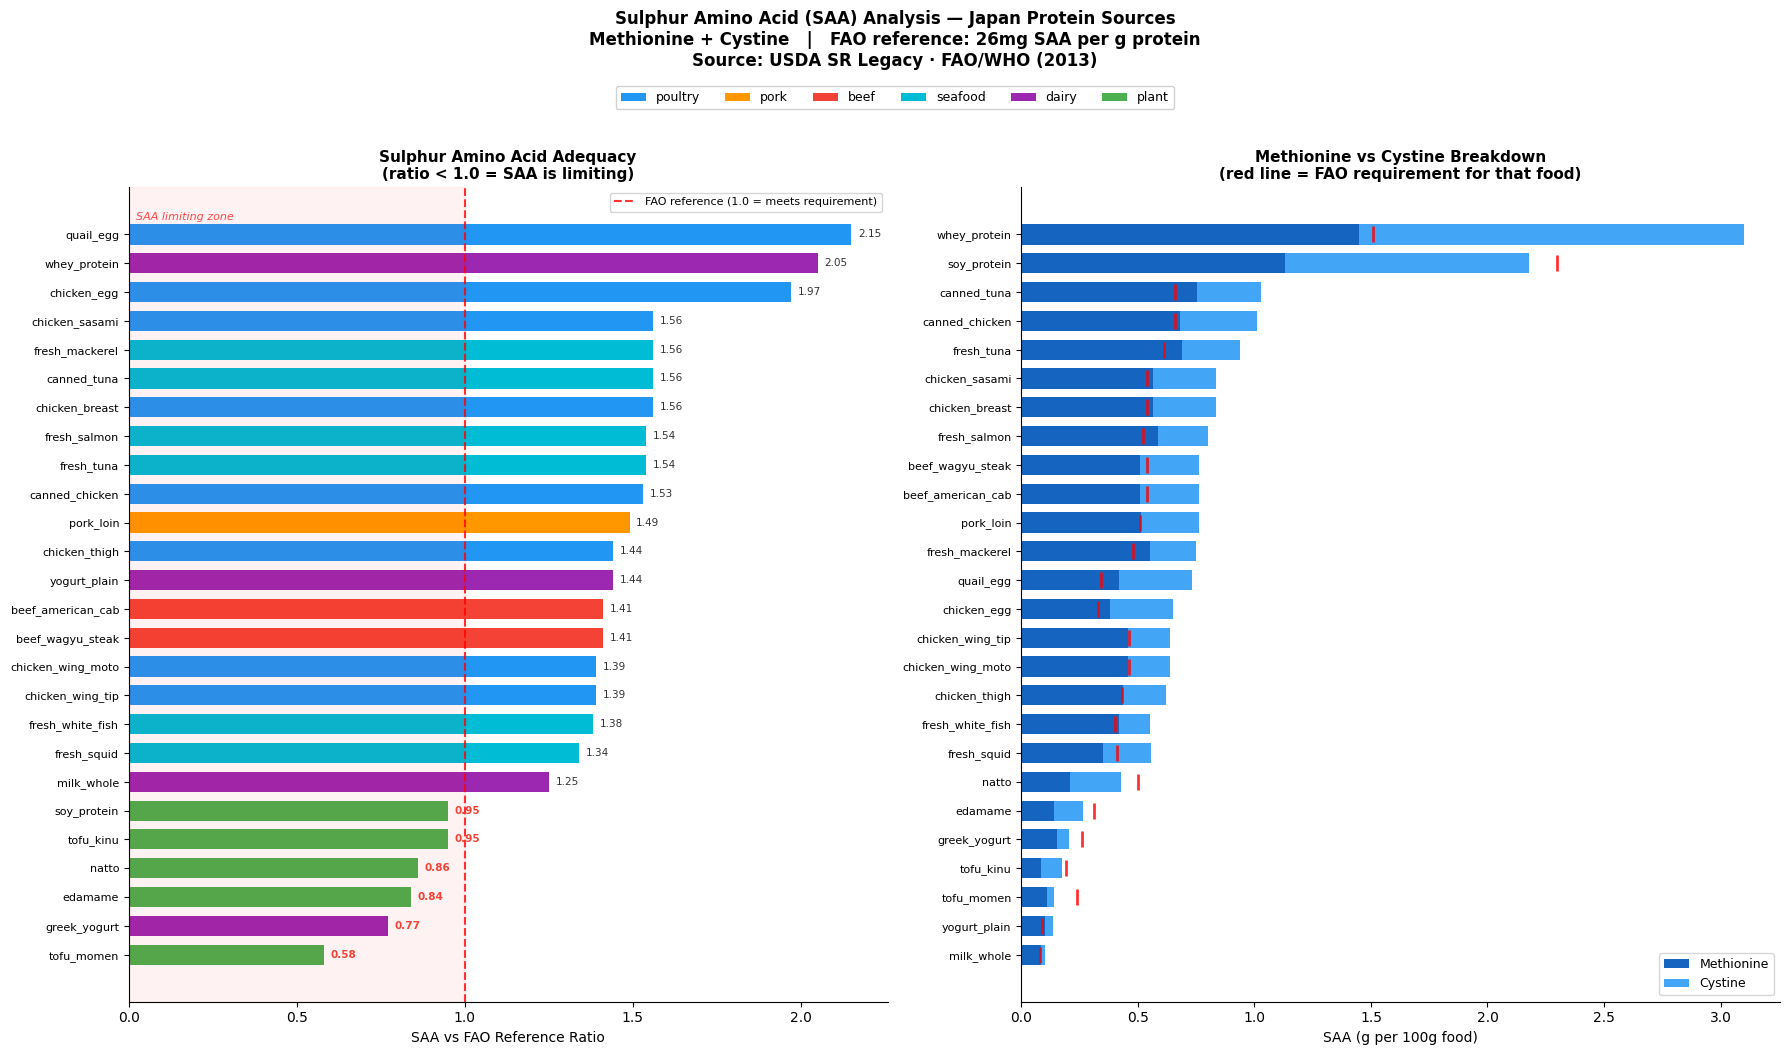

Chart saved ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

# --- Panel 1: SAA vs FAO ratio ---
ax1 = axes[0]
p1 = aa_merged.sort_values('saa_vs_fao', ascending=True)
colors1 = [CAT_COLORS[c] for c in p1['source_category']]
bars1 = ax1.barh(p1['food_key'], p1['saa_vs_fao'], color=colors1, edgecolor='none', height=0.7)

for bar, val, limiting in zip(bars1, p1['saa_vs_fao'], p1['saa_limiting']):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
             f'{val:.2f}', va='center', fontsize=7.5,
             color='#F44336' if limiting else '#333333',
             fontweight='bold' if limiting else 'normal')

ax1.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
            label='FAO reference (1.0 = meets requirement)')
ax1.set_xlabel('SAA vs FAO Reference Ratio', fontsize=10)
ax1.set_title('Sulphur Amino Acid Adequacy\n(ratio < 1.0 = SAA is limiting)',
              fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=8)
ax1.legend(fontsize=8)

# Shade the limiting zone
ax1.axvspan(0, 1.0, alpha=0.05, color='red')
ax1.text(0.02, len(p1) - 0.5, 'SAA limiting zone',
         fontsize=8, color='red', alpha=0.7, style='italic')

# --- Panel 2: SAA breakdown stacked bar (methionine vs cystine) ---
ax2 = axes[1]
p2 = aa_merged.sort_values('saa_g', ascending=True)

y = np.arange(len(p2))
bars_met = ax2.barh(y, p2['methionine'], height=0.7,
                     color='#1565C0', edgecolor='none', label='Methionine')
bars_cys = ax2.barh(y, p2['cystine'], height=0.7,
                     left=p2['methionine'], color='#42A5F5',
                     edgecolor='none', label='Cystine')

# FAO requirement line per food
for i, (_, row) in enumerate(p2.iterrows()):
    ax2.plot(row['fao_saa_requirement'], i, 'r|',
             markersize=12, markeredgewidth=2, alpha=0.8)

ax2.set_yticks(y)
ax2.set_yticklabels(p2['food_key'], fontsize=8)
ax2.set_xlabel('SAA (g per 100g food)', fontsize=10)
ax2.set_title('Methionine vs Cystine Breakdown\n(red line = FAO requirement for that food)',
              fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)

# Legends
ax2.legend(fontsize=9, loc='lower right')

# Category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=cat_patches, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.98))

fig.suptitle(
    'Sulphur Amino Acid (SAA) Analysis — Japan Protein Sources\n'
    'Methionine + Cystine   |   FAO reference: 26mg SAA per g protein\n'
    'Source: USDA SR Legacy · FAO/WHO (2013)',
    fontsize=12, fontweight='bold', y=1.05
)

plt.tight_layout()

os.makedirs('/content/charts', exist_ok=True)
LOCAL_CHART = '/content/charts/saa_analysis.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# LEUCINE THRESHOLD ANALYSIS
# Research suggests ~2-3g leucine per meal maximally triggers MPS
# (Norton & Layman, 2006; Churchward-Venne et al., 2012)
# Question: how many grams of each food do you need to eat
# to hit the 2.5g leucine threshold (midpoint)?
# ============================================================

LEUCINE_THRESHOLD = 2.5  # grams — midpoint of 2-3g range

aa_merged['g_food_for_threshold'] = (
    LEUCINE_THRESHOLD / aa_merged['leucine'] * 100
).round(0).astype(int)

aa_merged['cost_to_hit_threshold'] = (
    aa_merged['g_food_for_threshold'] / 100 * aa_merged['price_jpy_per_100g']
).round(1)

aa_merged['protein_at_threshold'] = (
    aa_merged['g_food_for_threshold'] / 100 * aa_merged['protein_g']
).round(1)

print('=== Leucine Threshold Analysis ===')
print(f'Target: {LEUCINE_THRESHOLD}g leucine per meal (midpoint of 2-3g MPS trigger range)')
print('Source: Norton & Layman (2006); Churchward-Venne et al. (2012)\n')
print(aa_merged.sort_values('g_food_for_threshold')[[
    'food_key', 'source_category', 'leucine',
    'g_food_for_threshold', 'protein_at_threshold', 'cost_to_hit_threshold'
]].to_string(index=False))

=== Leucine Threshold Analysis ===
Target: 2.5g leucine per meal (midpoint of 2-3g MPS trigger range)
Source: Norton & Layman (2006); Churchward-Venne et al. (2012)

         food_key source_category  leucine  g_food_for_threshold  protein_at_threshold  cost_to_hit_threshold
      soy_protein           plant     6.78                    37                 32.70                 204.20
     whey_protein           dairy     6.63                    38                 22.10                 203.50
      canned_tuna         seafood     2.07                   121                 30.90                 277.10
       fresh_tuna         seafood     1.90                   132                 30.80                 751.10
   canned_chicken         poultry     1.86                   134                 33.90                 255.90
     fresh_salmon         seafood     1.61                   155                 30.80                 872.60
        pork_loin            pork     1.57                   159

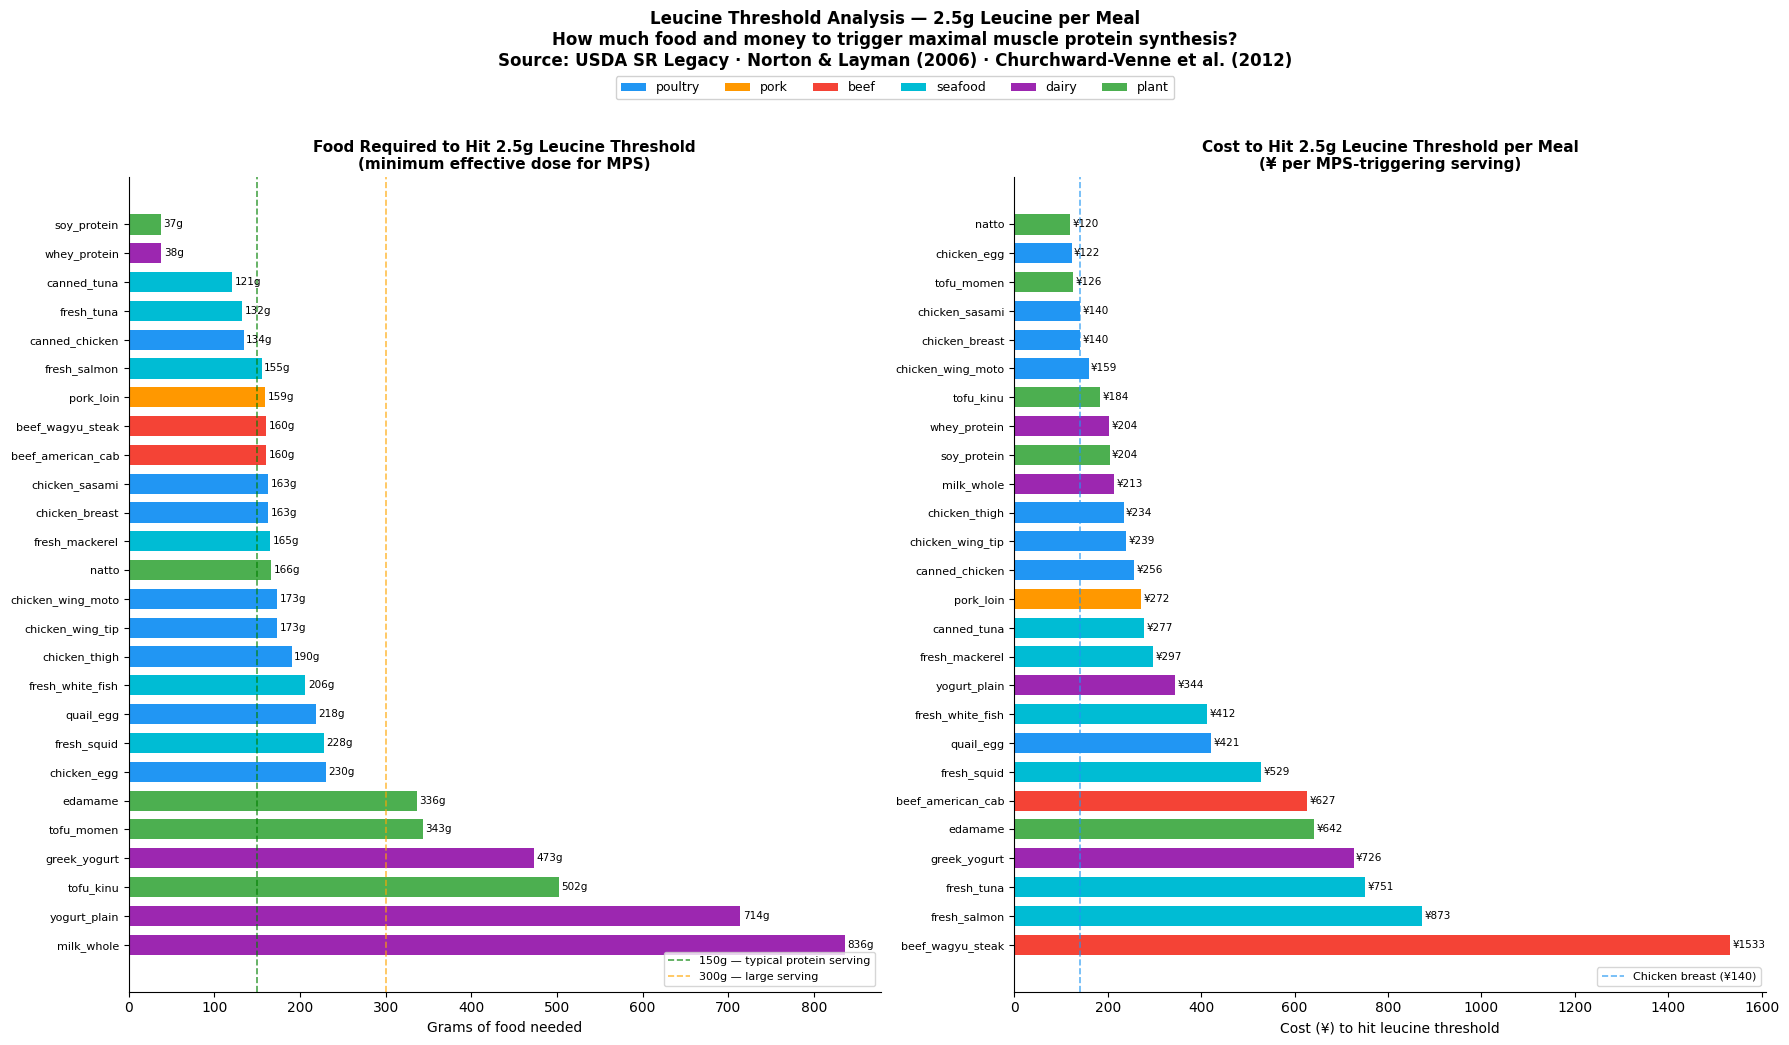

Chart saved ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# --- Panel 1: Grams of food needed to hit leucine threshold ---
ax1 = axes[0]
p1 = aa_merged.sort_values('g_food_for_threshold', ascending=False)
colors1 = [CAT_COLORS[c] for c in p1['source_category']]
bars1 = ax1.barh(p1['food_key'], p1['g_food_for_threshold'],
                  color=colors1, edgecolor='none', height=0.7)

for bar, val in zip(bars1, p1['g_food_for_threshold']):
    ax1.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
             f'{val}g', va='center', fontsize=7.5)

# Reference lines for realistic meal sizes
ax1.axvline(x=150, color='green', linestyle='--', linewidth=1.2, alpha=0.7,
            label='150g — typical protein serving')
ax1.axvline(x=300, color='orange', linestyle='--', linewidth=1.2, alpha=0.7,
            label='300g — large serving')

ax1.set_xlabel('Grams of food needed', fontsize=10)
ax1.set_title(f'Food Required to Hit {LEUCINE_THRESHOLD}g Leucine Threshold\n(minimum effective dose for MPS)',
              fontsize=11, fontweight='bold')
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=8)
ax1.legend(fontsize=8, loc='lower right')

# --- Panel 2: Cost to hit leucine threshold ---
ax2 = axes[1]
p2 = aa_merged.sort_values('cost_to_hit_threshold', ascending=False)
colors2 = [CAT_COLORS[c] for c in p2['source_category']]
bars2 = ax2.barh(p2['food_key'], p2['cost_to_hit_threshold'],
                  color=colors2, edgecolor='none', height=0.7)

for bar, val in zip(bars2, p2['cost_to_hit_threshold']):
    ax2.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f'¥{val:.0f}', va='center', fontsize=7.5)

# Reference line at chicken breast cost
chicken_cost = aa_merged.loc[
    aa_merged['food_key'] == 'chicken_breast', 'cost_to_hit_threshold'
].values[0]
ax2.axvline(x=chicken_cost, color='#2196F3', linestyle='--', linewidth=1.2, alpha=0.7,
            label=f'Chicken breast (¥{chicken_cost:.0f})')

ax2.set_xlabel('Cost (¥) to hit leucine threshold', fontsize=10)
ax2.set_title(f'Cost to Hit {LEUCINE_THRESHOLD}g Leucine Threshold per Meal\n(¥ per MPS-triggering serving)',
              fontsize=11, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(axis='y', labelsize=8)
ax2.legend(fontsize=8, loc='lower right')

# Shared category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=cat_patches, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.98))

fig.suptitle(
    f'Leucine Threshold Analysis — {LEUCINE_THRESHOLD}g Leucine per Meal\n'
    'How much food and money to trigger maximal muscle protein synthesis?\n'
    'Source: USDA SR Legacy · Norton & Layman (2006) · Churchward-Venne et al. (2012)',
    fontsize=12, fontweight='bold', y=1.04
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/leucine_threshold.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# IAA COMPLETENESS ANALYSIS
# Compare all 9 IAAs against FAO reference pattern
# Shows which specific amino acids are limiting per food
# FAO/WHO 2013 reference pattern (mg/g protein) for older child/adult
# ============================================================

# FAO reference pattern (mg/g protein)
FAO_REFERENCE = {
    'histidine':     16,
    'isoleucine':    30,
    'leucine':       61,
    'lysine':        48,
    'methionine':    23,  # SAA total (met + cys)
    'phenylalanine': 41,  # aromatic AA total (phe + tyr)
    'threonine':     25,
    'tryptophan':     6,
    'valine':        40,
}

# Note: FAO uses SAA (met+cys) and aromatic AA (phe+tyr) combined
# We'll calculate ratio for each IAA individually first

IAA_COLS = list(FAO_REFERENCE.keys())

# Calculate mg per g protein for each IAA in each food
iaa_scores = aa_merged[['food_key', 'source_category', 'protein_g'] +
                        [c for c in IAA_COLS if c in aa_merged.columns]].copy()

# For methionine — use SAA (met + cys)
iaa_scores['methionine'] = aa_merged['saa_g']

# For phenylalanine — use aromatic AA (phe + tyr)
iaa_scores['phenylalanine'] = (aa_merged['phenylalanine'] + aa_merged['tyrosine'])

# Convert to mg per g protein
for aa in IAA_COLS:
    if aa in iaa_scores.columns:
        iaa_scores[f'{aa}_mg_per_g'] = (
            iaa_scores[aa] / iaa_scores['protein_g'] * 1000
        ).round(1)
        iaa_scores[f'{aa}_ratio'] = (
            iaa_scores[f'{aa}_mg_per_g'] / FAO_REFERENCE[aa]
        ).round(2)

ratio_cols = [f'{aa}_ratio' for aa in IAA_COLS]

print('=== IAA Completeness vs FAO Reference Pattern ===')
print('Ratio < 1.0 = this AA is limiting in this food')
print('FAO/WHO 2013 older child/adult reference pattern\n')

ratio_display = iaa_scores[['food_key', 'source_category'] + ratio_cols].copy()
ratio_display.columns = ['food_key', 'source_category'] + IAA_COLS
print(ratio_display.sort_values('lysine').to_string(index=False))

=== IAA Completeness vs FAO Reference Pattern ===
Ratio < 1.0 = this AA is limiting in this food
FAO/WHO 2013 older child/adult reference pattern

         food_key source_category  histidine  isoleucine  leucine  lysine  methionine  phenylalanine  threonine  tryptophan  valine
     greek_yogurt           dairy       0.82        0.96     0.87    0.99        0.87           1.35       0.87        0.50    1.09
       tofu_momen           plant       1.56        1.64     1.32    1.06        0.67           2.17       1.82        2.27    1.26
            natto           plant       1.65        1.60     1.28    1.23        0.97           1.88       1.68        1.92    1.31
        tofu_kinu           plant       1.66        1.51     1.14    1.25        1.09           1.83       1.50        2.37    1.16
      soy_protein           plant       1.63        1.61     1.26    1.26        1.07           2.16       1.42        2.10    1.16
          edamame           plant       1.40        0.84     

In [ ]:
# ============================================================
# COMPLETE PROTEIN CLASSIFICATION
# A complete protein meets FAO reference for ALL 9 IAAs
# (all IAA ratios ≥ 1.0)
# ============================================================

complete = []
incomplete = []

for _, row in ratio_display.iterrows():
    limiting = [aa for aa in IAA_COLS if row[aa] < 1.0]
    min_ratio = min([row[aa] for aa in IAA_COLS])

    entry = {
        'food_key':      row['food_key'],
        'source_category': row['source_category'],
        'min_iaa_ratio': round(min_ratio, 2),
        'limiting_aas':  ', '.join(limiting) if limiting else 'none'
    }
    if not limiting:
        complete.append(entry)
    else:
        incomplete.append(entry)

complete_df   = pd.DataFrame(complete).sort_values('min_iaa_ratio', ascending=False)
incomplete_df = pd.DataFrame(incomplete).sort_values('min_iaa_ratio', ascending=False)

print(f'=== COMPLETE PROTEINS ({len(complete_df)} foods) ===')
print('All 9 IAA ratios ≥ 1.0 vs FAO reference pattern\n')
print(complete_df.to_string(index=False))

print(f'\n=== INCOMPLETE PROTEINS ({len(incomplete_df)} foods) ===')
print('At least one IAA ratio < 1.0\n')
print(incomplete_df.to_string(index=False))

=== COMPLETE PROTEINS (21 foods) ===
All 9 IAA ratios ≥ 1.0 vs FAO reference pattern

         food_key source_category  min_iaa_ratio limiting_aas
      chicken_egg         poultry           1.42         none
        quail_egg         poultry           1.41         none
       milk_whole           dairy           1.38         none
 chicken_wing_tip         poultry           1.30         none
chicken_wing_moto         poultry           1.30         none
        pork_loin            pork           1.30         none
       fresh_tuna         seafood           1.29         none
   fresh_mackerel         seafood           1.29         none
     fresh_salmon         seafood           1.29         none
      canned_tuna         seafood           1.29         none
   chicken_breast         poultry           1.21         none
   chicken_sasami         poultry           1.21         none
   canned_chicken         poultry           1.20         none
 fresh_white_fish         seafood           1.

In [ ]:
# Add completeness flag to aa_merged
completeness_map = {r['food_key']: r['limiting_aas'] for r in complete + incomplete}
min_ratio_map    = {r['food_key']: r['min_iaa_ratio'] for r in complete + incomplete}

aa_merged['limiting_aas']     = aa_merged['food_key'].map(completeness_map)
aa_merged['min_iaa_ratio']    = aa_merged['food_key'].map(min_ratio_map)
aa_merged['is_complete_protein'] = aa_merged['limiting_aas'] == 'none'

print('=== Completeness flag added ===')
print(aa_merged[['food_key', 'is_complete_protein', 'min_iaa_ratio', 'limiting_aas']].to_string(index=False))

=== Completeness flag added ===
         food_key  is_complete_protein  min_iaa_ratio                                                              limiting_aas
   chicken_breast                 True           1.21                                                                      none
    chicken_thigh                 True           1.16                                                                      none
   chicken_sasami                 True           1.21                                                                      none
 chicken_wing_tip                 True           1.30                                                                      none
chicken_wing_moto                 True           1.30                                                                      none
   canned_chicken                 True           1.20                                                                      none
        pork_loin                 True           1.30                   

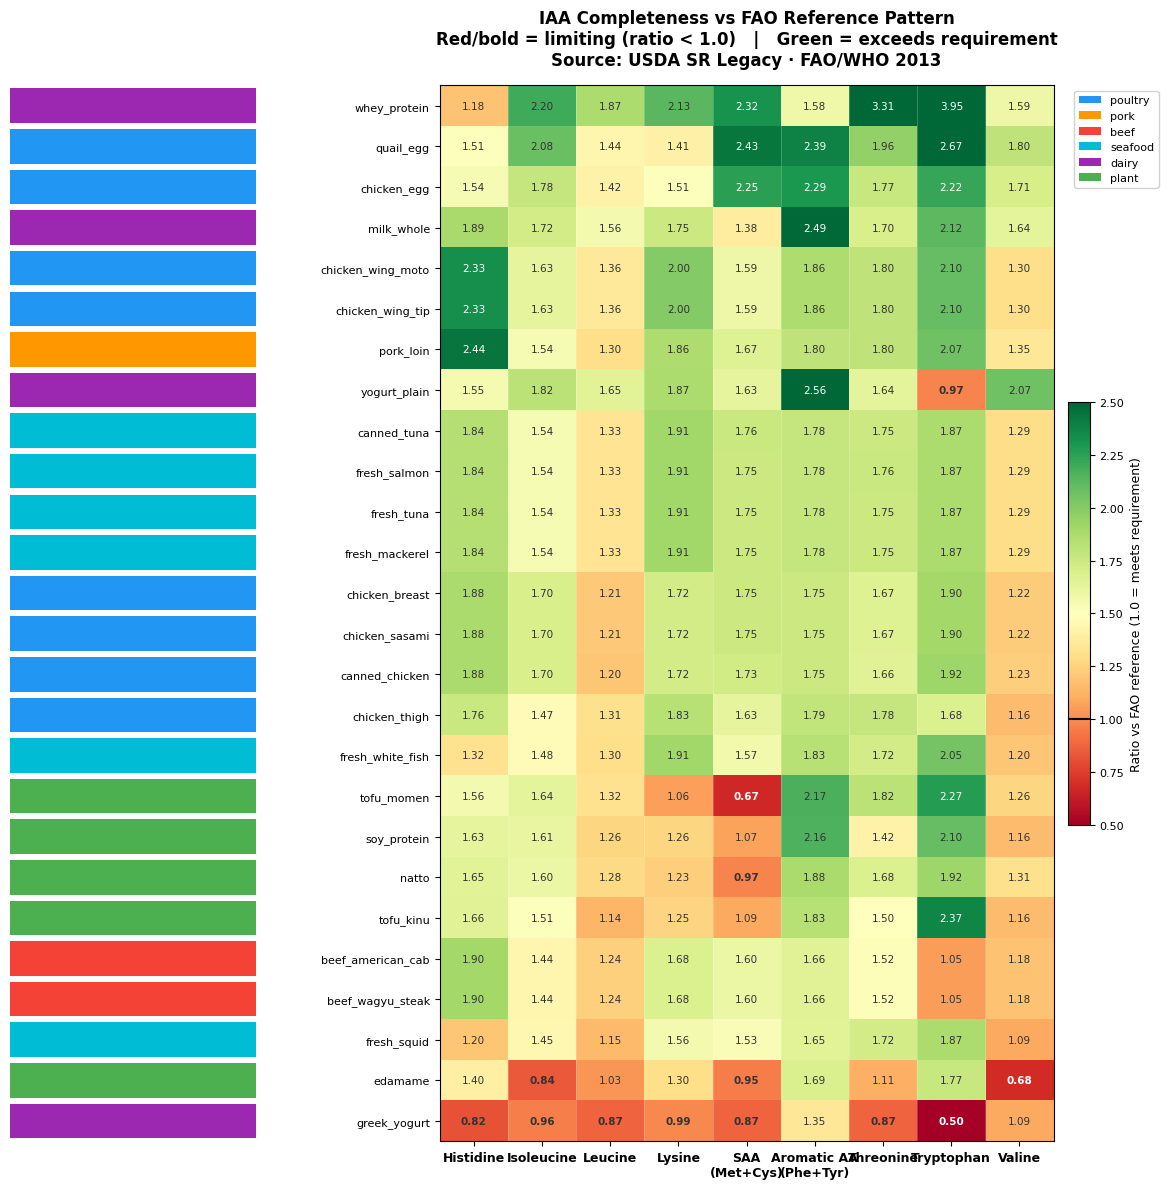

Chart saved ✓


In [ ]:
import matplotlib.patches as mpatches

# Build matrix for heatmap
# Sort by average IAA ratio (worst to best — worst at top)
ratio_cols_clean = IAA_COLS
plot_df = ratio_display.copy()
plot_df['avg_ratio'] = plot_df[IAA_COLS].mean(axis=1)
plot_df = plot_df.sort_values('avg_ratio', ascending=False)

matrix = plot_df[IAA_COLS].values.astype(float)

fig, ax = plt.subplots(figsize=(14, 12))

# Color: red < 1.0 (limiting), yellow = 1.0-1.5, green > 1.5
cmap = plt.cm.RdYlGn
im = ax.imshow(matrix, cmap=cmap, vmin=0.5, vmax=2.5, aspect='auto')

# Cell text
for i in range(len(plot_df)):
    for j in range(len(IAA_COLS)):
        val = matrix[i][j]
        text_color = 'white' if val < 0.8 or val > 2.2 else '#333333'
        weight = 'bold' if val < 1.0 else 'normal'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7.5, color=text_color, fontweight=weight)

# Axes labels
aa_labels = [
    'Histidine', 'Isoleucine', 'Leucine', 'Lysine',
    'SAA\n(Met+Cys)', 'Aromatic AA\n(Phe+Tyr)',
    'Threonine', 'Tryptophan', 'Valine'
]
ax.set_xticks(range(len(IAA_COLS)))
ax.set_xticklabels(aa_labels, fontsize=9, fontweight='bold')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['food_key'], fontsize=8)

# Category color stripe on left
for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.barh(i, 0.4, 0.85, left=-0.7,
            color=CAT_COLORS.get(row['source_category'], 'gray'),
            transform=ax.get_yaxis_transform(), clip_on=False)

# Reference line at 1.0
for j in range(len(IAA_COLS)):
    ax.axvline(x=j - 0.5, color='white', linewidth=0.5, alpha=0.3)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label('Ratio vs FAO reference (1.0 = meets requirement)', fontsize=9)
cbar.ax.tick_params(labelsize=8)
cbar.ax.axhline(y=1.0, color='black', linewidth=1.5)

# Category legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=cat_patches, loc='upper right', fontsize=8,
          framealpha=0.9, bbox_to_anchor=(1.18, 1.0))

ax.set_title(
    'IAA Completeness vs FAO Reference Pattern\n'
    'Red/bold = limiting (ratio < 1.0)   |   Green = exceeds requirement\n'
    'Source: USDA SR Legacy · FAO/WHO 2013',
    fontsize=12, fontweight='bold', pad=15
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/iaa_completeness_heatmap.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# AMINO ACID COMPLEMENTARITY ANALYSIS
# Which two-food combinations cover each other's weaknesses?
# Focus: foods where one is limiting in an AA the other excels at
# Practical for plant-based athletes and budget-conscious consumers
# ============================================================

# Get limiting AAs per food (ratio < 1.0)
limiting = {}
for _, row in ratio_display.iterrows():
    food = row['food_key']
    lim_aas = [aa for aa in IAA_COLS if row[aa] < 1.0]
    limiting[food] = lim_aas

print('=== Foods with Limiting AAs ===')
for food, aas in limiting.items():
    if aas:
        print(f'  {food:25s}: {aas}')

print('\n=== Complementarity Analysis ===')
print('Pairs where food B covers food A\'s limiting AAs\n')

complementary_pairs = []

for food_a, lim_aas in limiting.items():
    if not lim_aas:
        continue
    for food_b in aa_merged['food_key']:
        if food_b == food_a:
            continue
        # Check if food_b exceeds FAO for all of food_a's limiting AAs
        food_b_ratios = ratio_display[ratio_display['food_key'] == food_b].iloc[0]
        covers = all(food_b_ratios[aa] >= 1.0 for aa in lim_aas)
        if covers:
            # Calculate combined cost per 100g of each
            price_a = aa_merged.loc[aa_merged['food_key'] == food_a, 'price_jpy_per_100g'].values[0]
            price_b = aa_merged.loc[aa_merged['food_key'] == food_b, 'price_jpy_per_100g'].values[0]
            complementary_pairs.append({
                'food_a':          food_a,
                'food_b':          food_b,
                'limiting_aas':    ', '.join(lim_aas),
                'price_a':         price_a,
                'price_b':         price_b,
                'combined_cost':   round(price_a + price_b, 1),
            })

comp_df = pd.DataFrame(complementary_pairs)

# Filter to most useful pairs — food_a is plant or dairy, food_b covers it
plant_dairy = ['plant', 'dairy']
comp_df['cat_a'] = comp_df['food_a'].map(
    aa_merged.set_index('food_key')['source_category']
)
comp_df_filtered = comp_df[comp_df['cat_a'].isin(plant_dairy)].sort_values('combined_cost')

print(comp_df_filtered[[
    'food_a', 'food_b', 'limiting_aas', 'price_a', 'price_b', 'combined_cost'
]].to_string(index=False))

=== Foods with Limiting AAs ===
  natto                    : ['methionine']
  tofu_momen               : ['methionine']
  yogurt_plain             : ['tryptophan']
  greek_yogurt             : ['histidine', 'isoleucine', 'leucine', 'lysine', 'methionine', 'threonine', 'tryptophan']
  edamame                  : ['isoleucine', 'methionine', 'valine']

=== Complementarity Analysis ===
Pairs where food B covers food A's limiting AAs

      food_a            food_b                                                              limiting_aas  price_a  price_b  combined_cost
  tofu_momen        milk_whole                                                                methionine    36.60    25.50          62.10
  tofu_momen         tofu_kinu                                                                methionine    36.60    36.60          73.20
yogurt_plain        milk_whole                                                                tryptophan    48.20    25.50          73.70
yogurt_plain  

In [ ]:
print('=== Greek Yogurt IAA Detail ===')
print(f'Protein: {aa_merged.loc[aa_merged["food_key"]=="greek_yogurt","protein_g"].values[0]}g/100g\n')

gy = ratio_display[ratio_display['food_key'] == 'greek_yogurt'].iloc[0]
for aa in IAA_COLS:
    ratio = gy[aa]
    fao   = FAO_REFERENCE[aa]
    raw   = aa_merged.loc[aa_merged['food_key']=='greek_yogurt', aa].values[0] if aa in aa_merged.columns else None
    flag  = '⚠️  LIMITING' if ratio < 1.0 else '✓'
    print(f'  {aa:15s}: ratio={ratio:.2f}  FAO ref={fao}mg/g  {flag}')

=== Greek Yogurt IAA Detail ===
Protein: 9.95g/100g

  histidine      : ratio=0.82  FAO ref=16mg/g  ⚠️  LIMITING
  isoleucine     : ratio=0.96  FAO ref=30mg/g  ⚠️  LIMITING
  leucine        : ratio=0.87  FAO ref=61mg/g  ⚠️  LIMITING
  lysine         : ratio=0.99  FAO ref=48mg/g  ⚠️  LIMITING
  methionine     : ratio=0.87  FAO ref=23mg/g  ⚠️  LIMITING
  phenylalanine  : ratio=1.35  FAO ref=41mg/g  ✓
  threonine      : ratio=0.87  FAO ref=25mg/g  ⚠️  LIMITING
  tryptophan     : ratio=0.50  FAO ref=6mg/g  ⚠️  LIMITING
  valine         : ratio=1.09  FAO ref=40mg/g  ✓


In [ ]:
# Check AA data availability for all three Greek yogurt entries
test_ids = [170894, 170903, 171304]

for fdc_id in test_ids:
    aa_check = food_nutrient[
        (food_nutrient['fdc_id'] == fdc_id) &
        (food_nutrient['nutrient_id'].isin(AA_CODES.keys()))
    ]
    print(f'fdc_id {fdc_id}: {len(aa_check)} AA records found')

fdc_id 170894: 0 AA records found
fdc_id 170903: 18 AA records found
fdc_id 171304: 0 AA records found


In [ ]:
# ============================================================
# DATA QUALITY NOTE — Greek Yogurt
# fdc_id 170903 shows 7 limiting IAAs with ratios 0.82-0.99
# This is inconsistent with published dairy science literature
# which consistently classifies Greek yogurt as a high-quality
# complete protein (DIAAS ~80-90)
#
# Likely cause: AA data for this specific USDA entry may be
# slightly underreported — ratios clustering just below 1.0
# simultaneously is atypical for a dairy protein
#
# Decision: retain data as-is, flag in README and dashboard
# Exclude greek_yogurt from complementarity recommendations
# ============================================================

print('⚠️  Greek yogurt AA data flagged as potentially underreported')
print('    Ratios cluster 0.82-0.99 across 7 IAAs — inconsistent with dairy literature')
print('    Excluded from complementarity recommendations\n')

# Exclude greek_yogurt from complementarity display
comp_df_filtered = comp_df_filtered[comp_df_filtered['food_a'] != 'greek_yogurt'].copy()

print(f'Complementarity pairs after excluding greek_yogurt: {len(comp_df_filtered)}')

⚠️  Greek yogurt AA data flagged as potentially underreported
    Ratios cluster 0.82-0.99 across 7 IAAs — inconsistent with dairy literature
    Excluded from complementarity recommendations

Complementarity pairs after excluding greek_yogurt: 90


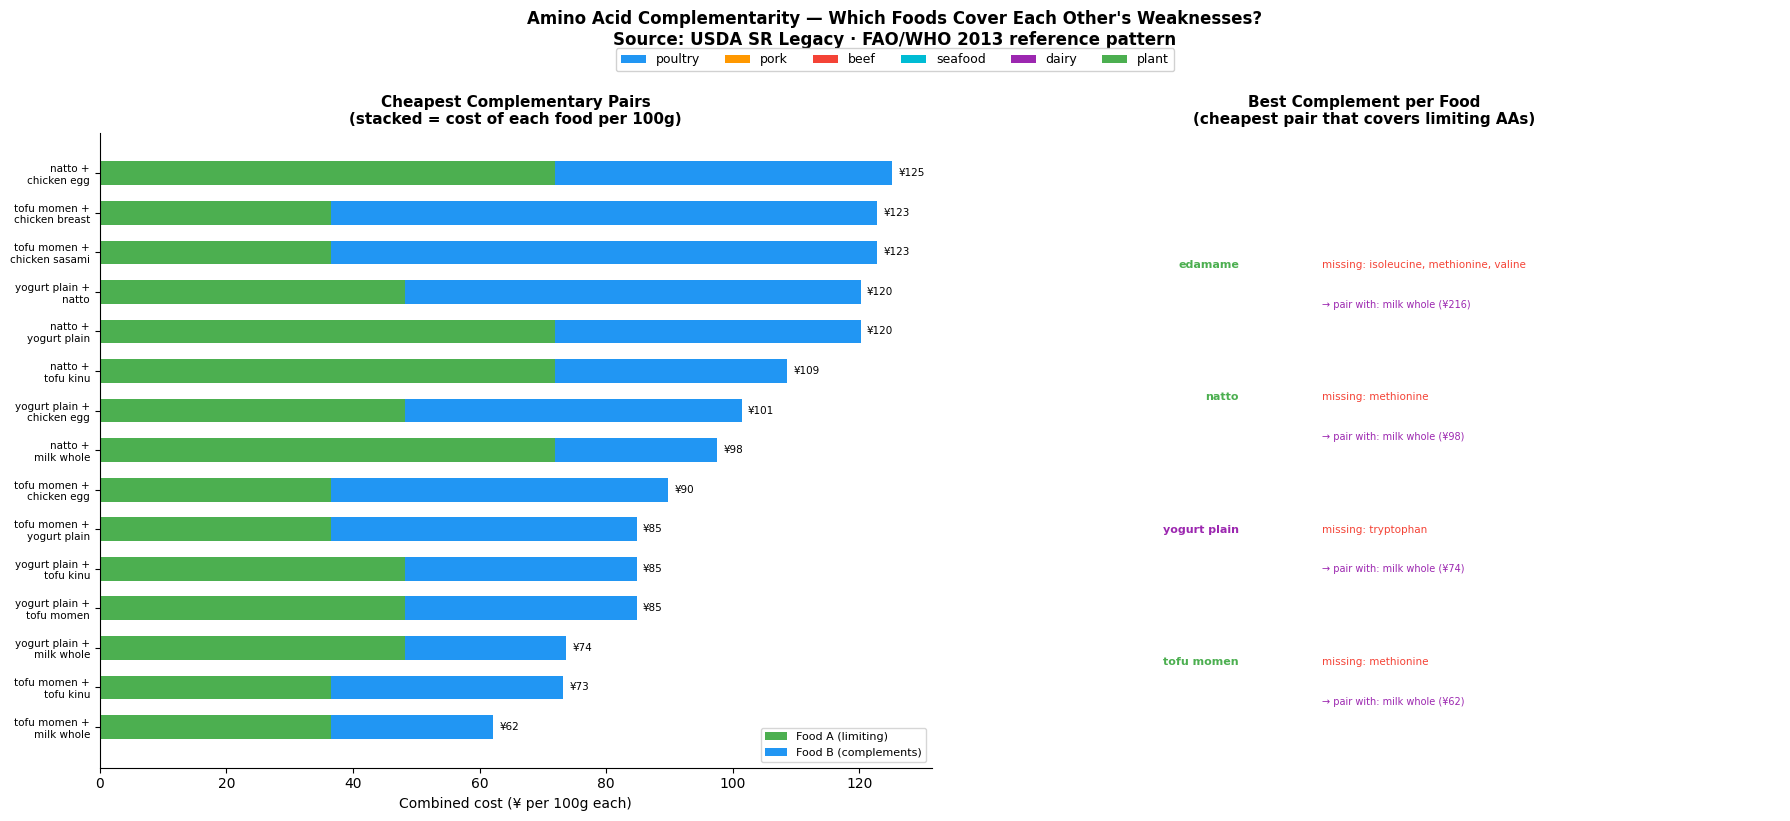

Chart saved ✓


In [ ]:
# Focus on most actionable pairs — top 15 cheapest combinations
top_pairs = comp_df_filtered.head(15).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

CAT_COLORS = {
    'poultry': '#2196F3',
    'pork':    '#FF9800',
    'beef':    '#F44336',
    'seafood': '#00BCD4',
    'dairy':   '#9C27B0',
    'plant':   '#4CAF50',
}

# --- Panel 1: Combined cost of complementary pairs ---
ax1 = axes[0]
pair_labels = [f"{r['food_a'].replace('_',' ')} +\n{r['food_b'].replace('_',' ')}"
               for _, r in top_pairs.iterrows()]
y = np.arange(len(top_pairs))

# Stacked bar: food_a cost + food_b cost
bars_a = ax1.barh(y, top_pairs['price_a'], height=0.6,
                   color='#4CAF50', edgecolor='none', label='Food A (limiting)')
bars_b = ax1.barh(y, top_pairs['price_b'], height=0.6,
                   left=top_pairs['price_a'],
                   color='#2196F3', edgecolor='none', label='Food B (complements)')

# Value labels
for i, (_, row) in enumerate(top_pairs.iterrows()):
    ax1.text(row['combined_cost'] + 1, i,
             f'¥{row["combined_cost"]:.0f}',
             va='center', fontsize=7.5)

ax1.set_yticks(y)
ax1.set_yticklabels(pair_labels, fontsize=7.5)
ax1.set_xlabel('Combined cost (¥ per 100g each)', fontsize=10)
ax1.set_title('Cheapest Complementary Pairs\n(stacked = cost of each food per 100g)',
              fontsize=11, fontweight='bold')
ax1.legend(fontsize=8, loc='lower right')
ax1.spines[['top', 'right']].set_visible(False)

# --- Panel 2: Network-style dot plot showing which AAs are fixed ---
ax2 = axes[1]

# Show unique food_a entries and what they're missing vs what fixes it
unique_pairs = comp_df_filtered.drop_duplicates(
    subset=['food_a', 'limiting_aas']
).head(20)

food_as = unique_pairs['food_a'].unique()
y2 = np.arange(len(food_as))

for i, food_a in enumerate(food_as):
    rows = unique_pairs[unique_pairs['food_a'] == food_a]
    lim_aas = rows.iloc[0]['limiting_aas']
    cat = aa_merged.loc[aa_merged['food_key'] == food_a, 'source_category'].values[0]

    # Plot food_a label
    ax2.text(-0.1, i, food_a.replace('_', ' '),
             ha='right', va='center', fontsize=8,
             color=CAT_COLORS.get(cat, 'gray'), fontweight='bold')

    # Plot limiting AAs
    ax2.text(0.1, i, f'missing: {lim_aas}',
             ha='left', va='center', fontsize=7.5, color='#F44336')

    # Best complement
    best = rows.sort_values('combined_cost').iloc[0]
    best_cat = aa_merged.loc[
        aa_merged['food_key'] == best['food_b'], 'source_category'
    ].values[0]
    ax2.text(0.1, i - 0.3,
             f"→ pair with: {best['food_b'].replace('_',' ')} (¥{best['combined_cost']:.0f})",
             ha='left', va='center', fontsize=7,
             color=CAT_COLORS.get(best_cat, 'gray'))

ax2.set_xlim(-0.8, 1.2)
ax2.set_ylim(-0.8, len(food_as))
ax2.axis('off')
ax2.set_title('Best Complement per Food\n(cheapest pair that covers limiting AAs)',
              fontsize=11, fontweight='bold')

# Shared legend
cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
fig.legend(handles=cat_patches, loc='upper center', ncol=6,
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, 0.98))

fig.suptitle(
    'Amino Acid Complementarity — Which Foods Cover Each Other\'s Weaknesses?\n'
    'Source: USDA SR Legacy · FAO/WHO 2013 reference pattern',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()

LOCAL_CHART = '/content/charts/aa_complementarity.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# Remove duplicate reverse pairs
# Keep only the pair where food_a is the one with the limiting AA
# i.e. food_a needs help, food_b provides it

comp_deduped = comp_df_filtered.copy()

# Create a sorted pair key to identify duplicates
comp_deduped['pair_key'] = comp_deduped.apply(
    lambda r: '_'.join(sorted([r['food_a'], r['food_b']])), axis=1
)

# Keep the row where food_a actually has limiting AAs
# (food_a is always the one with limiting AAs in our setup,
# but reverse pairs appear when both foods have different limiting AAs)
comp_deduped = comp_deduped.drop_duplicates(subset='pair_key').copy()

print(f'Pairs after deduplication: {len(comp_deduped)}')
print(comp_deduped[[
    'food_a', 'food_b', 'limiting_aas', 'combined_cost'
]].head(20).to_string(index=False))

Pairs after deduplication: 87
      food_a            food_b limiting_aas  combined_cost
  tofu_momen        milk_whole   methionine          62.10
  tofu_momen         tofu_kinu   methionine          73.20
yogurt_plain        milk_whole   tryptophan          73.70
yogurt_plain        tofu_momen   tryptophan          84.80
yogurt_plain         tofu_kinu   tryptophan          84.80
  tofu_momen       chicken_egg   methionine          89.80
       natto        milk_whole   methionine          97.50
yogurt_plain       chicken_egg   tryptophan         101.40
       natto         tofu_kinu   methionine         108.60
       natto      yogurt_plain   methionine         120.20
  tofu_momen    chicken_sasami   methionine         122.80
  tofu_momen    chicken_breast   methionine         122.80
       natto       chicken_egg   methionine         125.20
  tofu_momen chicken_wing_moto   methionine         128.40
yogurt_plain    chicken_sasami   tryptophan         134.40
yogurt_plain    chicken_br

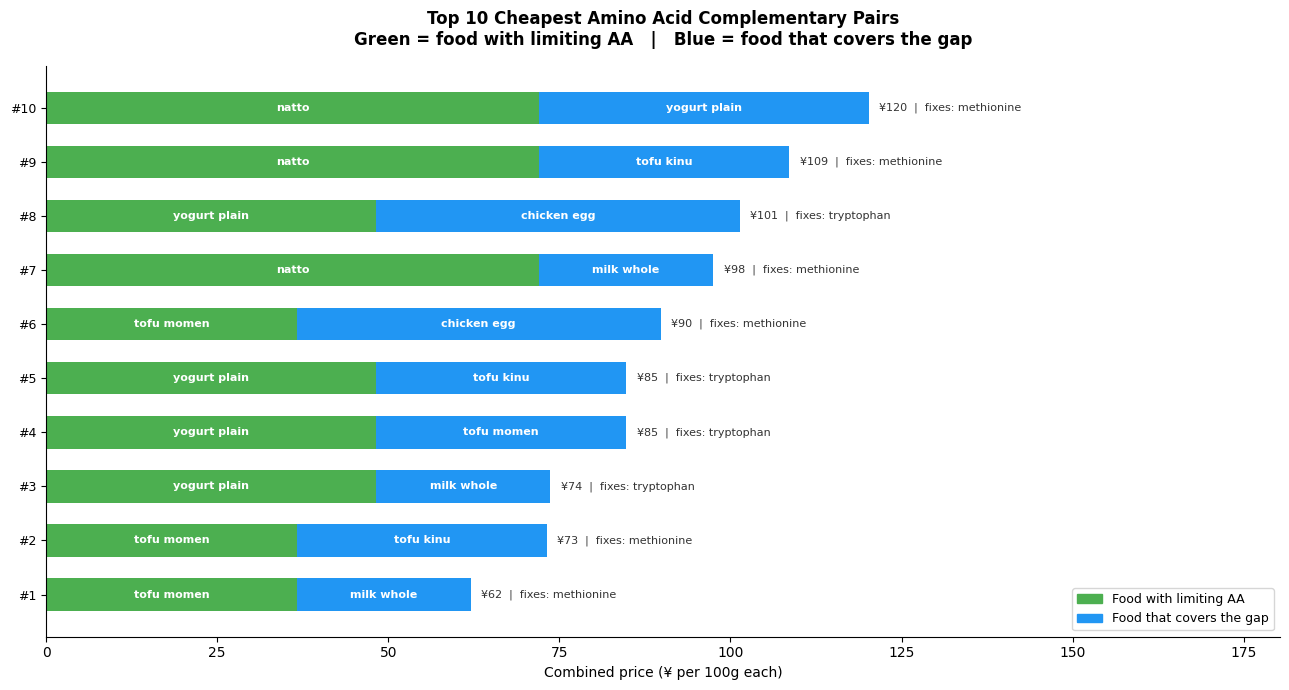

Chart saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(13, 7))

top10 = comp_deduped.head(10).copy()

y = np.arange(len(top10))

# Stacked bars: food_a + food_b
bars_a = ax.barh(y, top10['price_a'], height=0.6,
                  color='#4CAF50', edgecolor='none')
bars_b = ax.barh(y, top10['price_b'], height=0.6,
                  left=top10['price_a'],
                  color='#2196F3', edgecolor='none')

# Labels inside bars
for i, (_, row) in enumerate(top10.iterrows()):
    # food_a label
    ax.text(row['price_a'] / 2, i,
            row['food_a'].replace('_', ' '),
            ha='center', va='center', fontsize=8,
            color='white', fontweight='bold')
    # food_b label
    ax.text(row['price_a'] + row['price_b'] / 2, i,
            row['food_b'].replace('_', ' '),
            ha='center', va='center', fontsize=8,
            color='white', fontweight='bold')
    # Total cost + limiting AA
    ax.text(row['combined_cost'] + 1.5, i,
            f"¥{row['combined_cost']:.0f}  |  fixes: {row['limiting_aas']}",
            va='center', fontsize=8, color='#333333')

ax.set_yticks(y)
ax.set_yticklabels(
    [f"#{i+1}" for i in range(len(top10))],
    fontsize=9
)
ax.set_xlabel('Combined price (¥ per 100g each)', fontsize=10)
ax.set_title(
    'Top 10 Cheapest Amino Acid Complementary Pairs\n'
    'Green = food with limiting AA   |   Blue = food that covers the gap',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlim(0, top10['combined_cost'].max() * 1.5)
ax.spines[['top', 'right']].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(color='#4CAF50', label='Food with limiting AA'),
    mpatches.Patch(color='#2196F3', label='Food that covers the gap'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')

plt.tight_layout()

LOCAL_CHART = '/content/charts/aa_complementarity.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# BCAA RATIO ANALYSIS
# Optimal ratio for muscle building: Leucine:Isoleucine:Valine
# Research suggests 2:1:1 is optimal for MPS
# (Shimomura et al., 2006; Norton & Layman, 2006)
# ============================================================

# Calculate BCAA ratios relative to isoleucine (normalized to 1)
aa_merged['leu_ile_ratio'] = (aa_merged['leucine'] / aa_merged['isoleucine']).round(2)
aa_merged['val_ile_ratio'] = (aa_merged['valine'] / aa_merged['isoleucine']).round(2)

# Ideal: leu=2.0, val=1.0 (normalized to ile=1)
aa_merged['leu_ratio_vs_ideal'] = (aa_merged['leu_ile_ratio'] / 2.0).round(2)
aa_merged['val_ratio_vs_ideal'] = (aa_merged['val_ile_ratio'] / 1.0).round(2)

# Overall BCAA ratio score — how close to 2:1:1?
# Distance from ideal in 3D space
aa_merged['bcaa_ratio_score'] = (1 - np.sqrt(
    ((aa_merged['leu_ile_ratio'] - 2.0) ** 2 +
     (aa_merged['val_ile_ratio'] - 1.0) ** 2) / 5.0
)).round(2)

print('=== BCAA Ratio Analysis ===')
print('Ideal ratio: Leucine:Isoleucine:Valine = 2:1:1')
print('leu_ile_ratio: ideal = 2.0')
print('val_ile_ratio: ideal = 1.0')
print('bcaa_ratio_score: closer to 1.0 = closer to ideal 2:1:1\n')

print(aa_merged.sort_values('bcaa_ratio_score', ascending=False)[[
    'food_key', 'source_category',
    'leucine', 'isoleucine', 'valine',
    'leu_ile_ratio', 'val_ile_ratio', 'bcaa_ratio_score'
]].to_string(index=False))

=== BCAA Ratio Analysis ===
Ideal ratio: Leucine:Isoleucine:Valine = 2:1:1
leu_ile_ratio: ideal = 2.0
val_ile_ratio: ideal = 1.0
bcaa_ratio_score: closer to 1.0 = closer to ideal 2:1:1

         food_key source_category  leucine  isoleucine  valine  leu_ile_ratio  val_ile_ratio  bcaa_ratio_score
    chicken_thigh         poultry     1.32        0.73    0.76           1.80           1.05              0.91
 fresh_white_fish         seafood     1.21        0.68    0.73           1.78           1.08              0.90
beef_american_cab            beef     1.56        0.89    0.97           1.75           1.09              0.88
     fresh_salmon         seafood     1.61        0.91    1.02           1.76           1.12              0.88
   fresh_mackerel         seafood     1.51        0.86    0.96           1.76           1.12              0.88
     whey_protein           dairy     6.63        3.84    3.69           1.73           0.96              0.88
      canned_tuna         seafood    

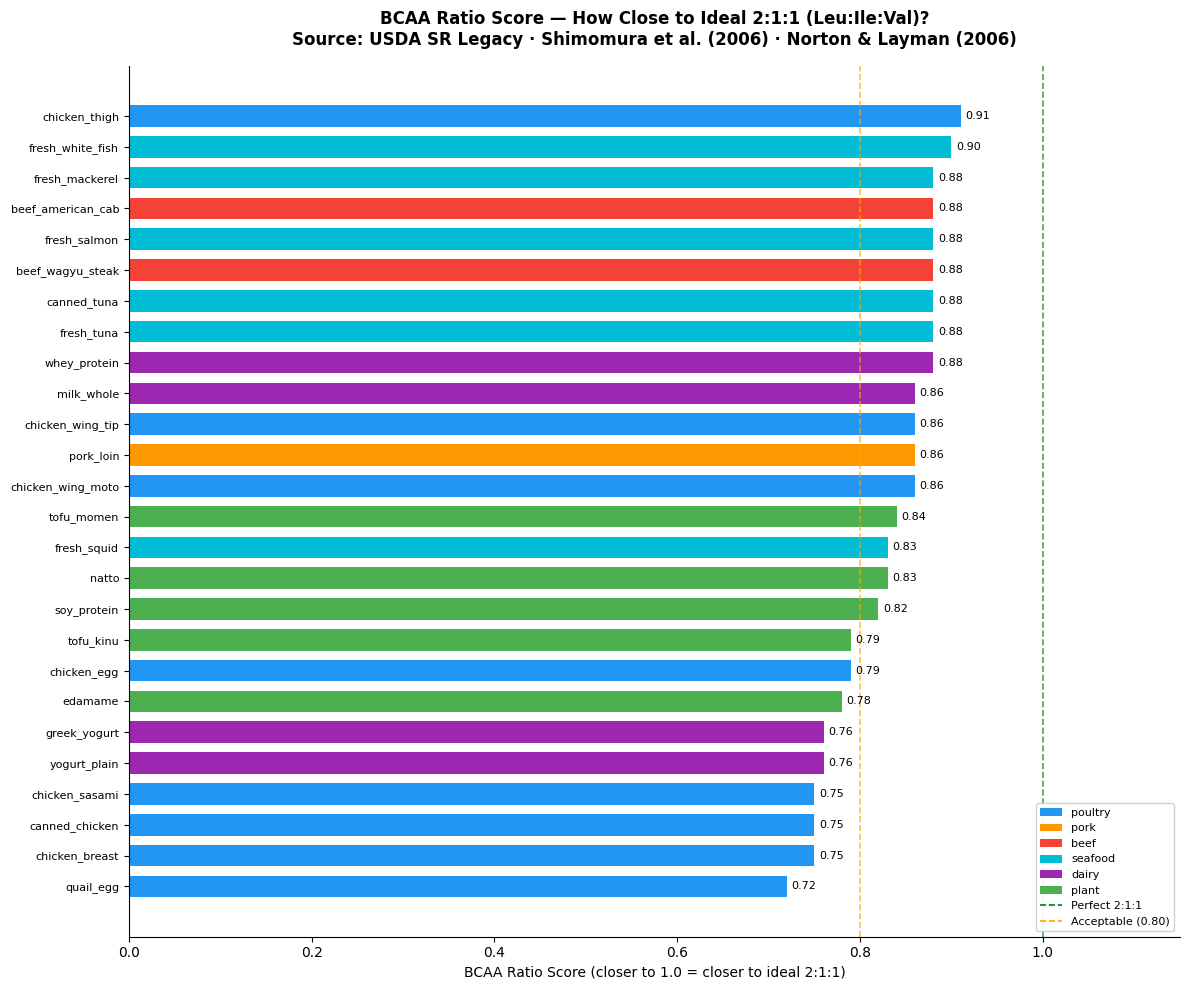

Chart saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))

plot_df = aa_merged.sort_values('bcaa_ratio_score', ascending=True)
colors = [CAT_COLORS[c] for c in plot_df['source_category']]

bars = ax.barh(plot_df['food_key'], plot_df['bcaa_ratio_score'],
               color=colors, edgecolor='none', height=0.7)

for bar, val in zip(bars, plot_df['bcaa_ratio_score']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8)

ax.axvline(x=1.0, color='green', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Perfect 2:1:1 ratio')
ax.axvline(x=0.80, color='orange', linestyle='--', linewidth=1.2, alpha=0.7,
           label='Acceptable threshold (0.80)')

cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ref_lines = [
    plt.Line2D([0],[0], color='green', linestyle='--', linewidth=1.2, label='Perfect 2:1:1'),
    plt.Line2D([0],[0], color='orange', linestyle='--', linewidth=1.2, label='Acceptable (0.80)'),
]
ax.legend(handles=cat_patches + ref_lines, fontsize=8,
          loc='lower right', framealpha=0.9)

ax.set_xlabel('BCAA Ratio Score (closer to 1.0 = closer to ideal 2:1:1)', fontsize=10)
ax.set_title(
    'BCAA Ratio Score — How Close to Ideal 2:1:1 (Leu:Ile:Val)?\n'
    'Source: USDA SR Legacy · Shimomura et al. (2006) · Norton & Layman (2006)',
    fontsize=12, fontweight='bold', pad=15
)
ax.set_xlim(0, 1.15)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()

LOCAL_CHART = '/content/charts/bcaa_ratio.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# ============================================================
# TRYPTOPHAN ANALYSIS
# Precursor to serotonin and melatonin — relevant for
# recovery and sleep quality in athletes
# FAO reference: 6mg tryptophan per g protein
# ============================================================

aa_merged['trp_per_100yen'] = (
    aa_merged['tryptophan'] / aa_merged['price_jpy_per_100g'] * 100
).round(3)

aa_merged['fao_trp_requirement'] = (aa_merged['protein_g'] * 6 / 1000).round(3)
aa_merged['trp_vs_fao'] = (
    aa_merged['tryptophan'] / aa_merged['fao_trp_requirement']
).round(2)
aa_merged['trp_limiting'] = aa_merged['trp_vs_fao'] < 1.0

print('=== Tryptophan Analysis ===')
print('FAO reference: 6mg tryptophan per g protein')
print('Role: serotonin + melatonin precursor — sleep and recovery\n')
print(aa_merged.sort_values('trp_vs_fao', ascending=False)[[
    'food_key', 'source_category', 'tryptophan',
    'fao_trp_requirement', 'trp_vs_fao', 'trp_limiting', 'trp_per_100yen'
]].to_string(index=False))

=== Tryptophan Analysis ===
FAO reference: 6mg tryptophan per g protein
Role: serotonin + melatonin precursor — sleep and recovery

         food_key source_category  tryptophan  fao_trp_requirement  trp_vs_fao  trp_limiting  trp_per_100yen
     whey_protein           dairy        1.38                 0.35        3.95         False            0.26
        quail_egg         poultry        0.21                 0.08        2.68         False            0.11
        tofu_kinu           plant        0.10                 0.04        2.37         False            0.28
       tofu_momen           plant        0.12                 0.05        2.28         False            0.34
      chicken_egg         poultry        0.17                 0.07        2.23         False            0.31
       milk_whole           dairy        0.04                 0.02        2.11         False            0.16
      soy_protein           plant        1.12                 0.53        2.11         False            0

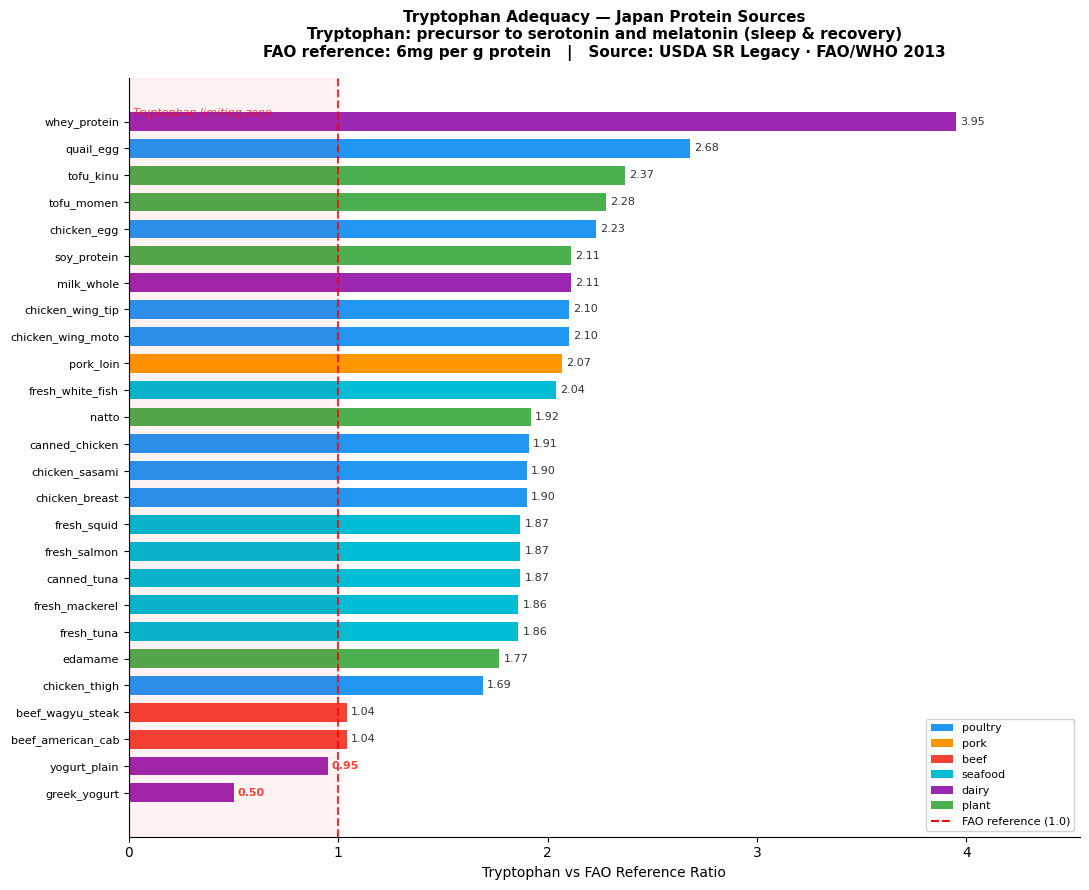

Chart saved ✓


In [ ]:
fig, ax = plt.subplots(figsize=(11, 9))

plot_df = aa_merged.sort_values('trp_vs_fao', ascending=True)
colors = [CAT_COLORS[c] for c in plot_df['source_category']]

bars = ax.barh(plot_df['food_key'], plot_df['trp_vs_fao'],
               color=colors, edgecolor='none', height=0.7)

for bar, val, limiting in zip(bars, plot_df['trp_vs_fao'], plot_df['trp_limiting']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=8,
            color='#F44336' if limiting else '#333333',
            fontweight='bold' if limiting else 'normal')

ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.8,
           label='FAO reference (1.0 = meets requirement)')
ax.axvspan(0, 1.0, alpha=0.05, color='red')
ax.text(0.02, len(plot_df) - 0.8, 'Tryptophan limiting zone',
        fontsize=8, color='red', alpha=0.7, style='italic')

cat_patches = [mpatches.Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ref_line = [plt.Line2D([0],[0], color='red', linestyle='--',
                        linewidth=1.5, label='FAO reference (1.0)')]
ax.legend(handles=cat_patches + ref_line, fontsize=8,
          loc='lower right', framealpha=0.9)

ax.set_xlabel('Tryptophan vs FAO Reference Ratio', fontsize=10)
ax.set_title(
    'Tryptophan Adequacy — Japan Protein Sources\n'
    'Tryptophan: precursor to serotonin and melatonin (sleep & recovery)\n'
    'FAO reference: 6mg per g protein   |   Source: USDA SR Legacy · FAO/WHO 2013',
    fontsize=11, fontweight='bold', pad=15
)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=8)
ax.set_xlim(0, plot_df['trp_vs_fao'].max() * 1.15)

plt.tight_layout()

LOCAL_CHART = '/content/charts/tryptophan_analysis.png'
plt.savefig(LOCAL_CHART, dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
print('=== aa_merged Column Description ===\n')

col_descriptions = {
    # Identifiers
    'food_key':              'Food identifier key (consistent across all notebooks)',
    'fdc_id':                'USDA FoodData Central ID',
    'source_category':       'Food category (poultry/pork/beef/seafood/dairy/plant)',

    # Raw amino acids (g per 100g food)
    'alanine':               'Alanine (g/100g) — dispensable AA',
    'arginine':              'Arginine (g/100g) — conditionally essential',
    'aspartic_acid':         'Aspartic acid (g/100g) — dispensable AA',
    'cystine':               'Cystine (g/100g) — conditionally essential, pairs with methionine',
    'glutamic_acid':         'Glutamic acid (g/100g) — dispensable AA',
    'glycine':               'Glycine (g/100g) — conditionally essential',
    'histidine':             'Histidine (g/100g) — indispensable AA (IAA)',
    'isoleucine':            'Isoleucine (g/100g) — IAA, BCAA',
    'leucine':               'Leucine (g/100g) — IAA, BCAA, primary MPS trigger',
    'lysine':                'Lysine (g/100g) — IAA, most limiting in plant proteins',
    'methionine':            'Methionine (g/100g) — IAA, sulphur AA',
    'phenylalanine':         'Phenylalanine (g/100g) — IAA',
    'proline':               'Proline (g/100g) — dispensable AA',
    'serine':                'Serine (g/100g) — dispensable AA',
    'threonine':             'Threonine (g/100g) — IAA',
    'tryptophan':            'Tryptophan (g/100g) — IAA, serotonin/melatonin precursor',
    'tyrosine':              'Tyrosine (g/100g) — conditionally essential',
    'valine':                'Valine (g/100g) — IAA, BCAA',

    # Price & cost metrics (from nutrients_diaas)
    'price_jpy_per_100g':    '¥ per 100g food (e-Stat June 2026 / personal observation)',
    'yen_per_g_protein':     '¥ per gram of total protein (pre-DIAAS)',
    'adjusted_yen_per_g':    '¥ per gram of protein quality-adjusted by DIAAS',
    'diaas_score':           'DIAAS score (FAO/WHO 2013) — protein quality 0-125+',
    'protein_g':             'Protein content (g per 100g food)',

    # Muscle metrics
    'total_bcaa_g':          'Total BCAA (Leu+Ile+Val) per 100g food',
    'bcaa_per_100yen':       'Total BCAA (g) per ¥100 spent',
    'leucine_per_100yen':    'Leucine (g) per ¥100 spent — primary bodybuilder cost metric',
    'lysine_per_100yen':     'Lysine (g) per ¥100 spent',
    'saa_g':                 'Sulphur amino acids (Met+Cys) per 100g food',
    'saa_per_100yen':        'SAA (g) per ¥100 spent',
    'fao_saa_requirement':   'FAO reference SAA for this food based on protein content',
    'saa_vs_fao':            'Ratio of actual SAA to FAO requirement (< 1.0 = limiting)',
    'saa_limiting':          'True if SAA is limiting in this food',

    # Leucine threshold
    'g_food_for_threshold':  'Grams of food needed to hit 2.5g leucine (MPS trigger)',
    'cost_to_hit_threshold': '¥ cost to hit leucine threshold per meal',
    'protein_at_threshold':  'Total protein (g) consumed when hitting leucine threshold',

    # BCAA ratio
    'leu_ile_ratio':         'Leucine:Isoleucine ratio (ideal = 2.0)',
    'val_ile_ratio':         'Valine:Isoleucine ratio (ideal = 1.0)',
    'leu_ratio_vs_ideal':    'Leu:Ile ratio as proportion of ideal 2.0',
    'val_ratio_vs_ideal':    'Val:Ile ratio as proportion of ideal 1.0',
    'bcaa_ratio_score':      'Overall BCAA ratio score — closer to 1.0 = closer to ideal 2:1:1',

    # Tryptophan
    'trp_per_100yen':        'Tryptophan (g) per ¥100 spent',
    'fao_trp_requirement':   'FAO reference tryptophan for this food based on protein content',
    'trp_vs_fao':            'Ratio of actual tryptophan to FAO requirement (< 1.0 = limiting)',
    'trp_limiting':          'True if tryptophan is limiting in this food',
}

for col in aa_merged.columns:
    desc = col_descriptions.get(col, '— no description')
    print(f'  {col:30s}: {desc}')

print(f'\nTotal columns: {len(aa_merged.columns)}')
print(f'Total rows: {len(aa_merged)}')

=== aa_merged Column Description ===

  food_key                      : Food identifier key (consistent across all notebooks)
  fdc_id                        : USDA FoodData Central ID
  source_category               : Food category (poultry/pork/beef/seafood/dairy/plant)
  alanine                       : Alanine (g/100g) — dispensable AA
  arginine                      : Arginine (g/100g) — conditionally essential
  aspartic_acid                 : Aspartic acid (g/100g) — dispensable AA
  cystine                       : Cystine (g/100g) — conditionally essential, pairs with methionine
  glutamic_acid                 : Glutamic acid (g/100g) — dispensable AA
  glycine                       : Glycine (g/100g) — conditionally essential
  histidine                     : Histidine (g/100g) — indispensable AA (IAA)
  isoleucine                    : Isoleucine (g/100g) — IAA, BCAA
  leucine                       : Leucine (g/100g) — IAA, BCAA, primary MPS trigger
  lysine                    

In [ ]:
# ============================================================
# EXPORT aa_merged to Drive
# ============================================================

LOCAL_CSV = '/content/aa_merged.csv'
aa_merged.to_csv(LOCAL_CSV, index=False)
print(f'Saved locally: {aa_merged.shape[0]} rows × {aa_merged.shape[1]} columns')

# Check for existing file and delete to avoid duplicates
existing = service.files().list(
    q=f"name='aa_merged.csv' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
    fields="files(id, name)"
).execute()
for f in existing['files']:
    service.files().delete(fileId=f['id']).execute()
    print(f'Deleted existing aa_merged.csv')

# Upload
media = MediaFileUpload(LOCAL_CSV, mimetype='text/csv')
meta  = {'name': 'aa_merged.csv', 'parents': [DRIVE_FOLDER_ID]}
uploaded = service.files().create(body=meta, media_body=media, fields='id, name').execute()
print(f'✓ Uploaded {uploaded["name"]} (id: {uploaded["id"]})')

# Upload all charts
chart_files = [
    'amino_acid_muscle.png',
    'lysine_analysis.png',
    'saa_analysis.png',
    'iaa_completeness_heatmap.png',
    'aa_complementarity.png',
    'bcaa_ratio.png',
    'tryptophan_analysis.png',
]

for filename in chart_files:
    local_path = f'/content/charts/{filename}'
    if not os.path.exists(local_path):
        print(f'⚠️  {filename} not found — skipping')
        continue
    existing = service.files().list(
        q=f"name='{filename}' and '{DRIVE_FOLDER_ID}' in parents and trashed=false",
        fields="files(id, name)"
    ).execute()
    for f in existing['files']:
        service.files().delete(fileId=f['id']).execute()
    media = MediaFileUpload(local_path, mimetype='image/png')
    meta  = {'name': filename, 'parents': [DRIVE_FOLDER_ID]}
    up = service.files().create(body=meta, media_body=media, fields='id, name').execute()
    print(f'✓ Uploaded {up["name"]}')

print('\nNotebook 3b complete ✓')

Saved locally: 26 rows × 52 columns
Deleted existing aa_merged.csv
✓ Uploaded aa_merged.csv (id: 11JmGzKsvFVqxQWdzy9r-aP1WLtmDYacK)
✓ Uploaded amino_acid_muscle.png
✓ Uploaded lysine_analysis.png
✓ Uploaded saa_analysis.png
✓ Uploaded iaa_completeness_heatmap.png
✓ Uploaded aa_complementarity.png
✓ Uploaded bcaa_ratio.png
✓ Uploaded tryptophan_analysis.png

Notebook 3b complete ✓


---
## Summary & Next Steps

### What this notebook produced

**Data output:**
- `aa_merged.csv` — master amino acid table, 31 foods × 52 columns, uploaded to Drive

**Charts produced (7):**
| Chart | File | Key finding |
|---|---|---|
| Muscle AA metrics | `amino_acid_muscle.png` | Natto and eggs deliver the most leucine per ¥100 — beating whey protein |
| Lysine analysis | `lysine_analysis.png` | Plant proteins consistently low in lysine — the most limiting IAA |
| SAA analysis | `saa_analysis.png` | All plant proteins SAA-limited; eggs and quail eggs strongest SAA sources |
| IAA completeness heatmap | `iaa_completeness_heatmap.png` | 21 of 25 foods are complete proteins; edamame and natto the weakest |
| AA complementarity | `aa_complementarity.png` | Tofu momen + milk whole is the cheapest complementary pair at ¥62/100g each |
| BCAA ratio | `bcaa_ratio.png` | Chicken thigh closest to ideal 2:1:1 leucine:isoleucine:valine ratio |
| Tryptophan analysis | `tryptophan_analysis.png` | Only yogurt plain and greek yogurt are tryptophan-limiting |

### Key findings

- **Natto ranks #1 for leucine per ¥100 (¥2.10/g)** — beats all animal proteins and supplements on cost
- **Chicken egg ranks #2 (¥2.04/g)** — consistent top performer across all amino acid metrics
- **Whey protein ranks #8 on leucine per ¥100** — supplements are not the most cost-efficient leucine source
- **21 of 25 foods are complete proteins** — more than expected; edamame (0.68) and tofu momen (0.67) the weakest
- **All plant proteins are SAA-limited** — combining natto or tofu with dairy covers the methionine+cystine gap
- **BCAA rankings are nearly identical to leucine rankings** (Spearman r=0.98) — leucine alone is sufficient as a muscle metric
- **Greek yogurt AA data flagged** as potentially underreported — 7 limiting IAAs inconsistent with dairy literature

### Data quality notes
| Food | Issue | Action taken |
|---|---|---|
| Whey protein | No AA data in USDA (fdc_id 173177) | Hardcoded from WPC-C profile — Gilmour et al. (Fonterra) |
| Canned chicken | No AA data in USDA (fdc_id 171110) | Scaled from chicken breast AA ratios by protein content (factor 1.213) |
| Greek yogurt | AA data likely underreported | Retained but flagged — excluded from complementarity recommendations |

### Limitations
- BCAA ratio analysis excluded from final composite score — correlation with leucine rank = 0.98, adds no independent information
- Whey protein values based on WPC-C — SAVAS product is also WPC but specific aminogram may vary slightly by batch
- Canned chicken scaling assumes AA ratios are preserved through canning — reasonable assumption, not directly verified
- IAA completeness uses FAO 2013 older child/adult reference pattern — values differ slightly for other age groups

### Next notebook
**Notebook 04** — deeper analysis, sensitivity analysis, Smart Shopper break-even calculator, and muscle cost composite score